# CCO07: Starts fresh again

In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import glob
import numpy as np
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import anndata
import os
import scipy

In [2]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07

In [3]:
PREV_DIR = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO06"
WORK_DIR = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO07"

In [4]:
import warnings
pd.options.mode.chained_assignment = None
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)

# 1. Change label and start from doublet filtered

In [4]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/adata/doublet_filtered
# ln -s /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/adata/doublet_filtered/* /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/adata/doublet_filtered

mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/adata/cell_type_labelled

In [5]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/dotplots
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/umaps

In [4]:
samples = ['ALL','VO','HO','CA','VHO','VCO']
samples_old = ['ALL','BVO','HO','CM3O','BHO','CM3B']

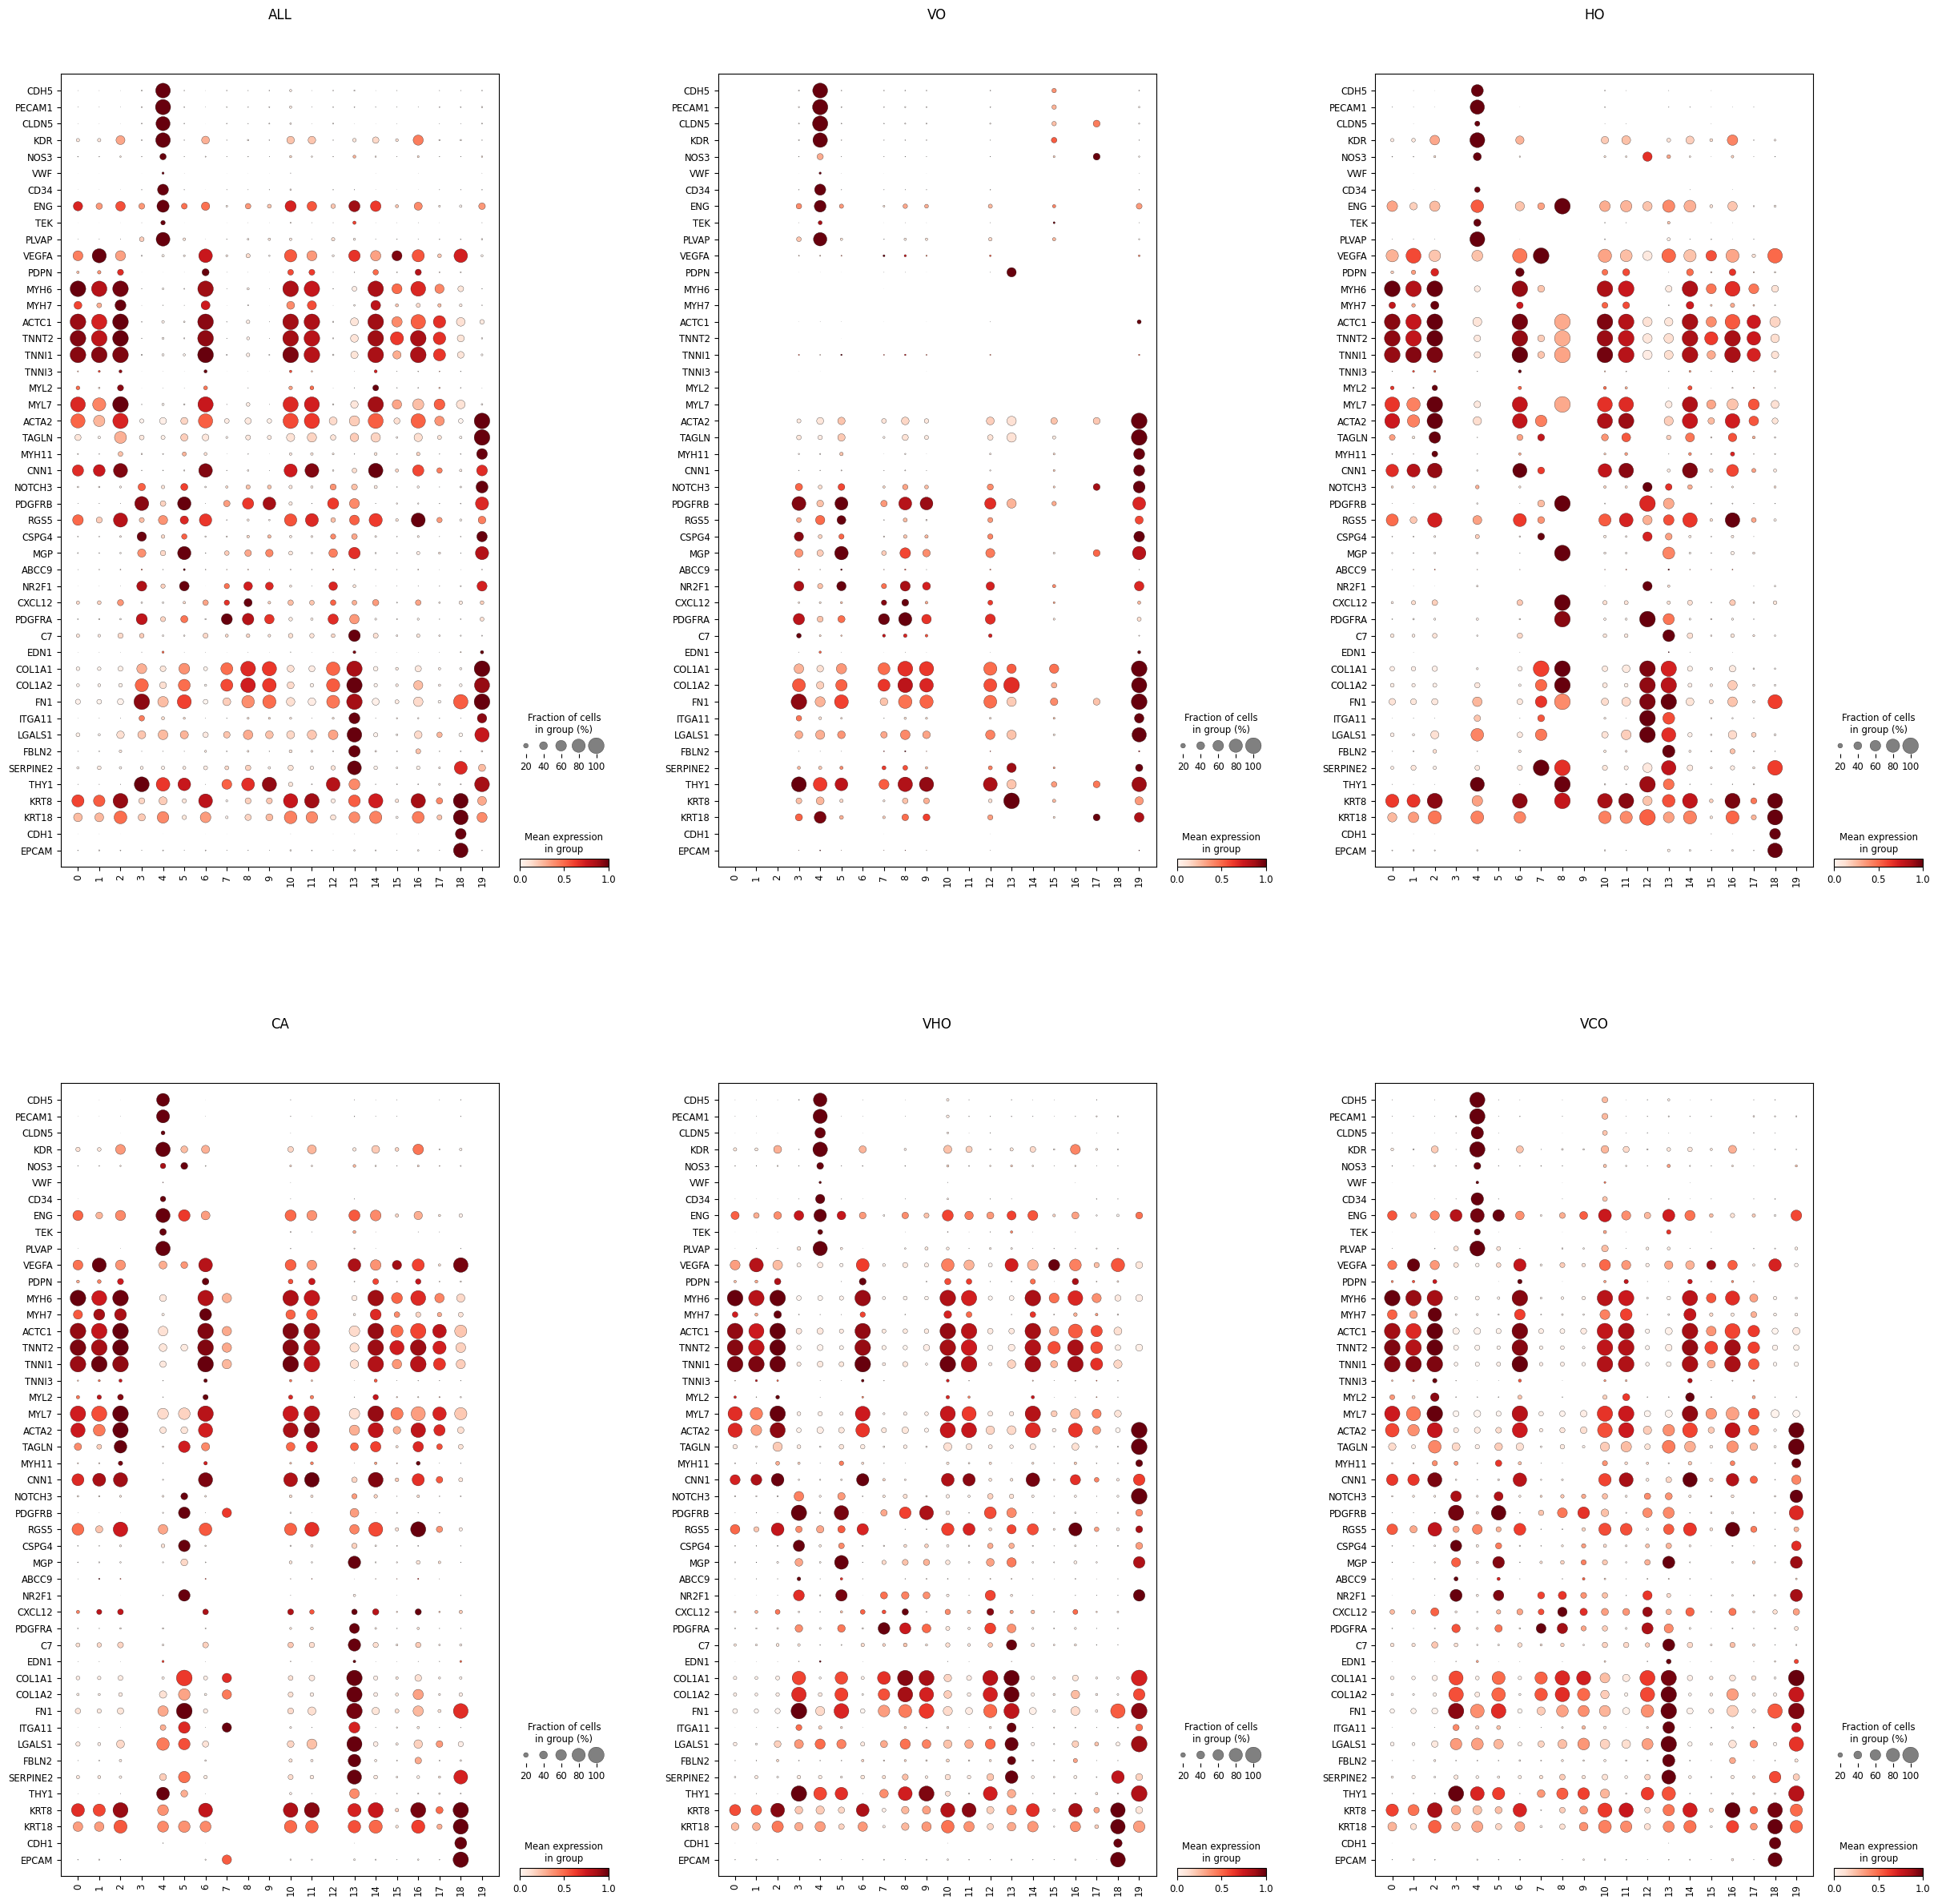

In [13]:
# marker_dict = ['CDH5', 'PECAM1', 'NOS3', 'VWF', 'CD34', 'ENG', 'FLT1', 'TEK', 'PDPN', 'MYH6', 
#                'MYH7', 'ACTC1', 'TNNT2', 'TNNI3', 'TNNI1', 'MYL2', 'MYL7', 'ACTA2', 'TAGLN', 'MYH11', 
#                'CNN1', 'DES', 'SMTN', 'VIM', 'CALD1', 'ELN', 'MYLK', 'S100A4', 'PDGFRA', 'THY1', 
#                'COL1A1', 'PDGFRB', 'CSPG4', 'RGS5', 'MCAM', 'NES', 'ITGB3', 'TGFBR1', 'TGFBR2', 'WT1', 
#                'TBX18', 'KRT8', 'KRT18', 'CDH1', 'EPCAM', 'SHH', 'RARA']

marker_dict = [
    "CDH5", "PECAM1", "CLDN5", "KDR", "NOS3", "VWF", "CD34", "ENG", "TEK", "PLVAP",
    "VEGFA", "PDPN", "MYH6", "MYH7", "ACTC1", "TNNT2", "TNNI1", "TNNI3", "MYL2", "MYL7",
    "ACTA2", "TAGLN", "MYH11", "CNN1", "NOTCH3", "PDGFRB", "RGS5", "CSPG4", "MGP", "ABCC9",
    "NR2F1", "CXCL12", "PDGFRA", "C7", "EDN1", "COL1A1", "COL1A2", "FN1", "ITGA11", "LGALS1",
    "FBLN2", "SERPINE2", "THY1", "KRT8", "KRT18", "CDH1", "EPCAM"
]

fig, axs = plt.subplots(2, 3, figsize=(30,30), layout="constrained")
axs = axs.flatten()

# for i, d1 in enumerate(glob.glob(f'{WORK_DIR}/adata/doublet_filtered/*.h5ad')):
#     sample_name = d1.split('/')[-1].strip('.h5ad')
#     adata = sc.read_h5ad(d1)

for i, sample_name in enumerate(samples):
    d1 = f"{WORK_DIR}/adata/doublet_filtered/{sample_name}.h5ad"
    adata = sc.read_h5ad(d1)
    
    adata.obs['leiden'] = adata.obs['leiden'].astype("int")
    for j in range(0, 20):
        if (adata.obs['leiden'] == j).any():
            continue
        else:
            pat = adata[0].copy()
            pat.obs['leiden'][0] = j
            pat.X.data[:] = 0
            adata = adata.concatenate(pat, batch_key='batch')
    adata.obs['leiden'] = adata.obs['leiden'].astype("category")
    
    sc.pl.dotplot(adata, marker_dict, groupby="leiden", standard_scale="var", ax=axs[i], title=sample_name, show=False, swap_axes=True)
    
plt.savefig(f'{WORK_DIR}/dotplots/original_laiden.complete.png')
plt.savefig(f'{WORK_DIR}/dotplots/original_laiden.complete.svg')
plt.show()

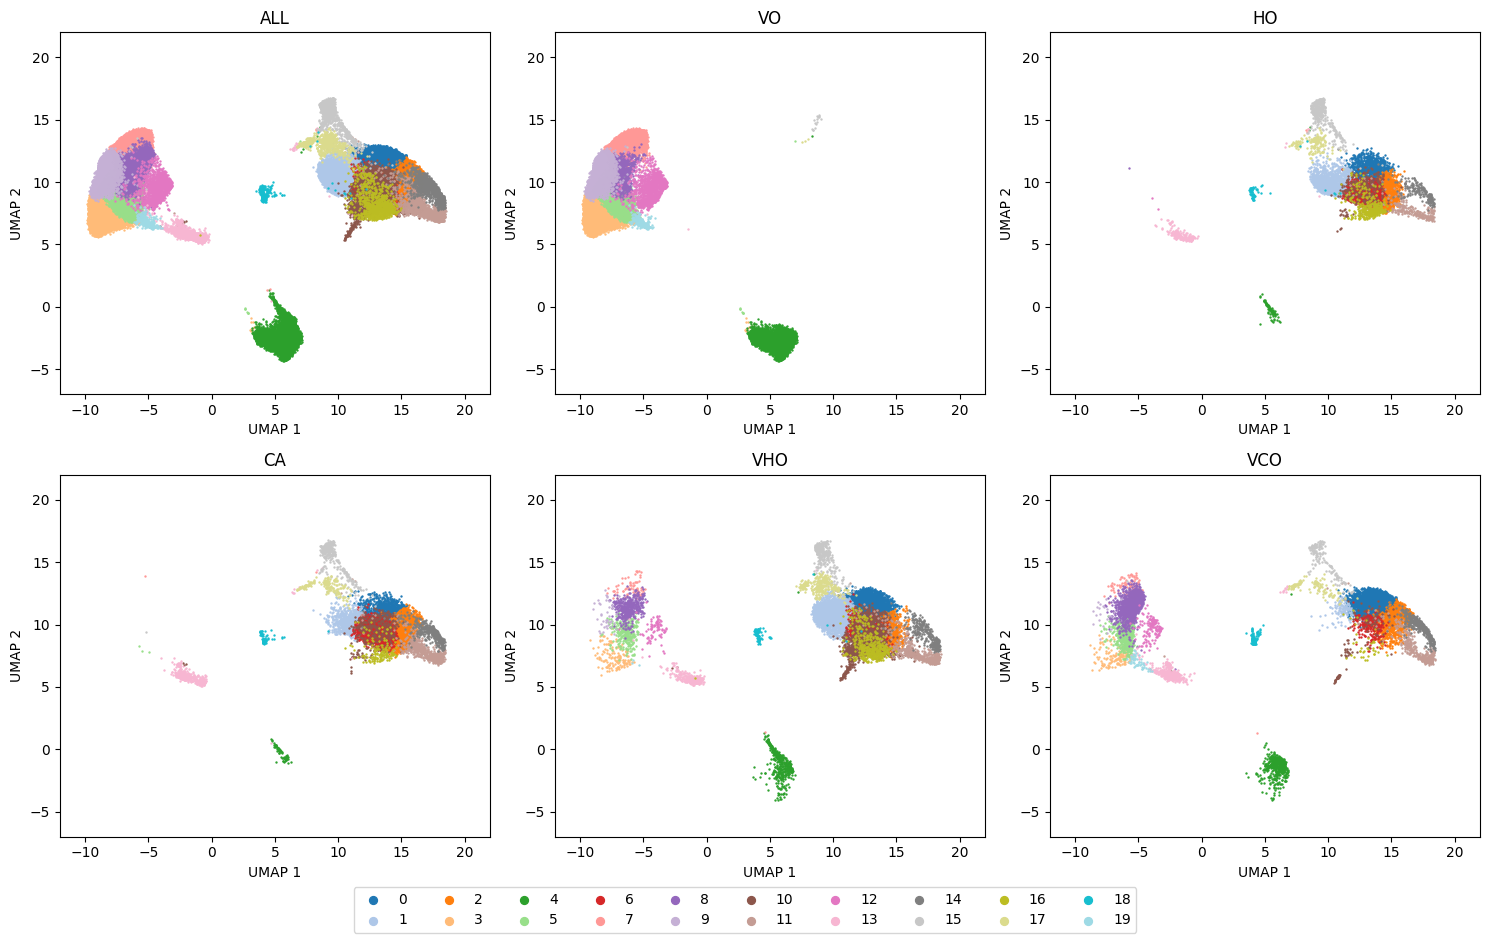

In [23]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

cell_types = ['CM','EC','EP','MU','UN']
cmap = plt.get_cmap('viridis')
colors = plt.get_cmap('tab20').colors
colormap_complete = {}
for i in range(0, 20):
    colormap_complete[str(i)] = colors[i]

handles = []
labels = []

for i, sample in enumerate(samples):
    
    adata = sc.read_h5ad(f'{WORK_DIR}/adata/doublet_filtered/{sample}.h5ad')
    
    for j, ld in enumerate(adata.obs["leiden"].unique().sort_values()):
        sbplt = axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['leiden'] == ld, 0], 
            adata.obsm['X_umap'][adata.obs['leiden'] == ld, 1], 
            label=ld, 
            color=colormap_complete[ld], 
            s=0.5)
        if i == 0:
            handles.append(sbplt)
            labels.append(ld)
        
    # axs[i].legend(loc='lower left', markerscale=5, ncol=2)
    axs[i].set_xlabel('UMAP 1')
    axs[i].set_ylabel('UMAP 2')
    axs[i].set_title(sample)
    axs[i].set_xlim([-12, 22])
    axs[i].set_ylim([-7, 22])

fig.legend(
    handles, labels,
    loc='lower center',
    ncol=10,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.05)
)
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/umaps/original_leiden.complete.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/umaps/original_leiden.complete.svg', bbox_inches="tight")
plt.show()

In [24]:
samples = ['ALL','VO','HO','CA','VHO','VCO']
samples_old = ['ALL','BVO','HO','CM3O','BHO','CM3B']

celltypes_dict = {
    '0': 'CM', 
    '1': 'CM',
    '2': 'CM',
    '3': 'MU',
    '4': 'EC',
    '5': 'MU',
    '6': 'CM',
    '7': 'MU',
    '8': 'MU',
    '9': 'MU',
    '10': 'CM',
    '11': 'CM',
    '12': 'MU',
    '13': 'MU',
    '14': 'CM',
    '15': 'UN',
    '16': 'CM',
    '17': 'UN',
    '18': 'EP',
    '19': 'MU',
}

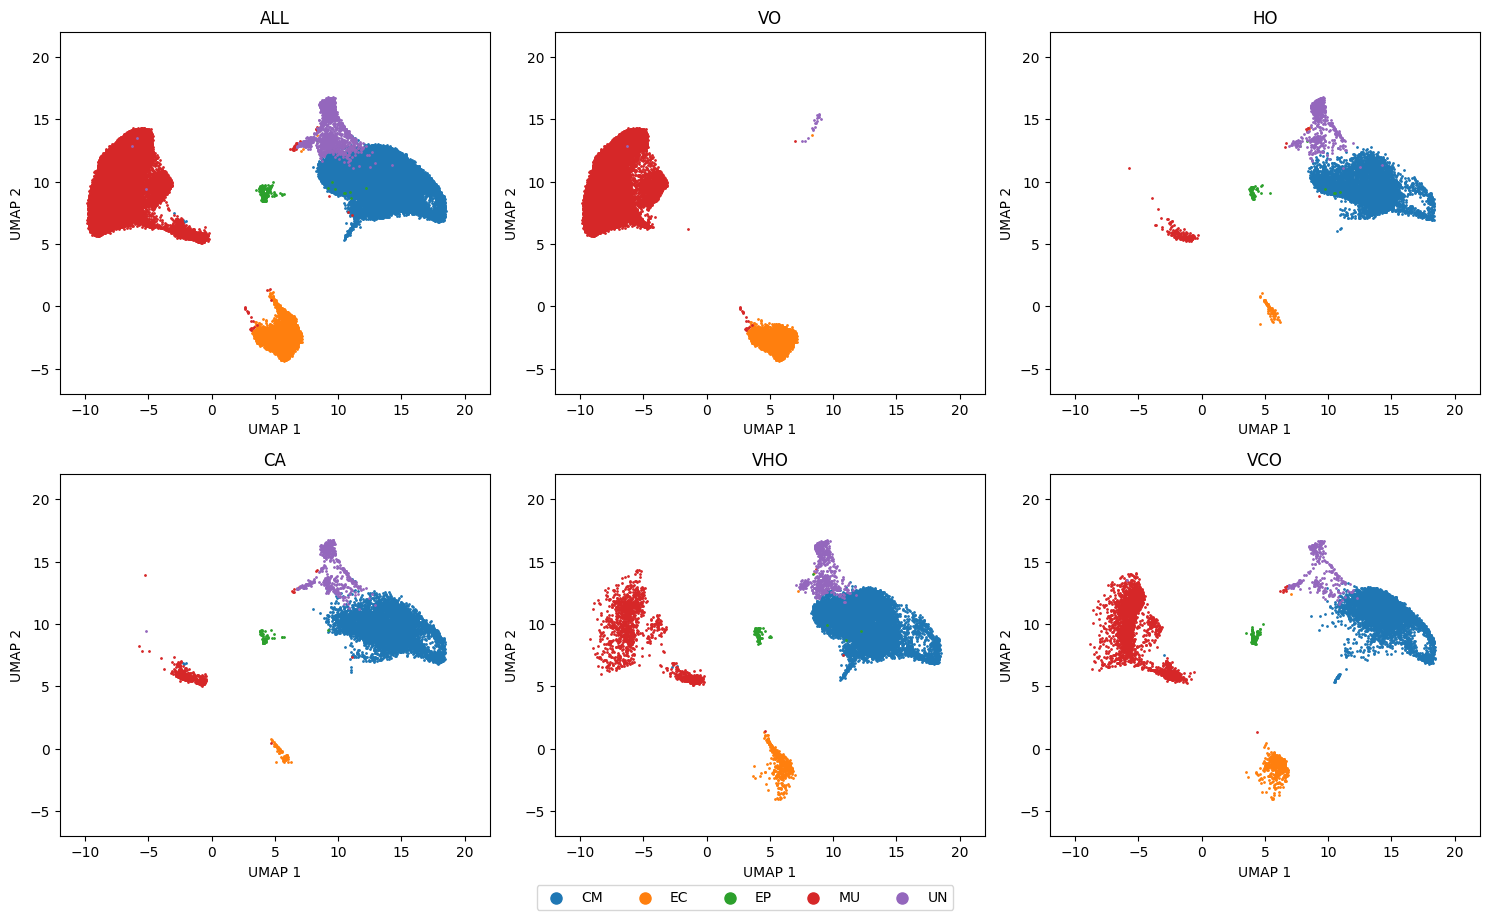

In [26]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

cell_types = ['CM','EC','EP','MU','UN']
cmap = plt.get_cmap('viridis')
colors = plt.get_cmap('tab10').colors
colormap_complete = {}
for i, ct in enumerate(cell_types):
    colormap_complete[ct] = colors[i]

batch_mapper = dict(zip(samples_old, samples))

handles = []
labels = []

for i, sample in enumerate(samples):
    
    adata = sc.read_h5ad(f'{WORK_DIR}/adata/doublet_filtered/{sample}.h5ad')
    adata.obs['cell_type'] = adata.obs['leiden'].map(celltypes_dict)
    
    adata.obs['batch'] = adata.obs['batch'].astype('str')
    adata.obs['batch'] = adata.obs['batch'].map(batch_mapper)
    adata.obs['batch'] = adata.obs['batch'].astype('category')
    
    adata.write(f'{WORK_DIR}/adata/cell_type_labelled/{sample}.h5ad')
    
    for j, ct in enumerate(cell_types):
        sbplt = axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['cell_type'] == ct, 0], 
            adata.obsm['X_umap'][adata.obs['cell_type'] == ct, 1], 
            label=ct, 
            color=colormap_complete[ct], 
            s=1)
        if i == 0:
            handles.append(sbplt)
            labels.append(ct)
        
    axs[i].set_xlabel('UMAP 1')
    axs[i].set_ylabel('UMAP 2')
    axs[i].set_title(sample)
    axs[i].set_xlim([-12, 22])
    axs[i].set_ylim([-7, 22])

fig.legend(
    handles, labels,
    loc='lower center',
    ncol=5,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.025)
)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/umaps/original_celltype.complete.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/umaps/original_celltype.complete.svg', bbox_inches="tight")
plt.show()

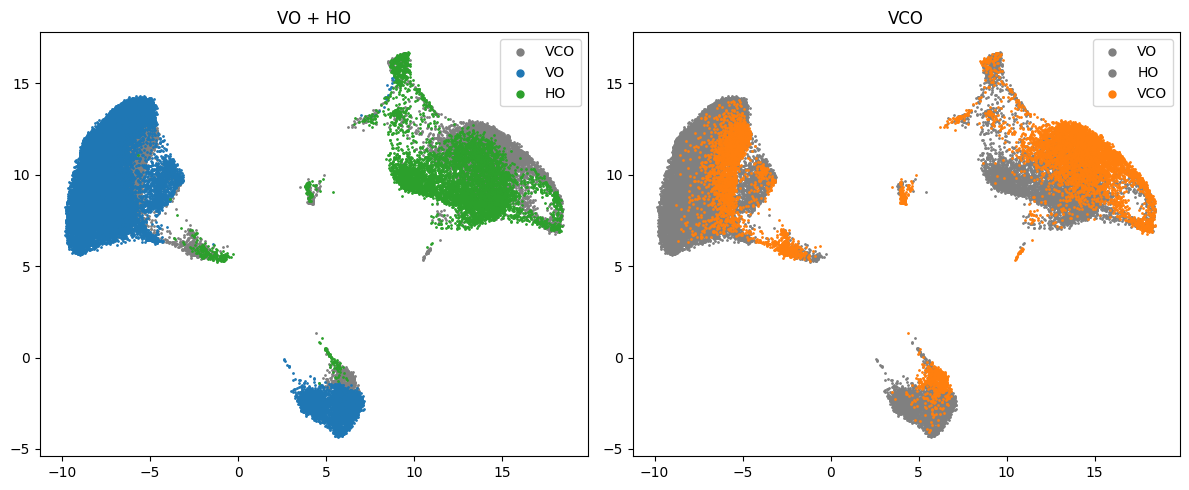

In [30]:
bc1 = "VO"
bc2 = "HO"
bc3 = "VCO"

adata_all = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_labelled/ALL.h5ad")
adata_vo = adata_all[adata_all.obs['batch'] == bc1]
adata_ho = adata_all[adata_all.obs['batch'] == bc2]
adata_vco = adata_all[adata_all.obs['batch'] == bc3]

fig, axs = plt.subplots(1, 2, figsize=(12,5))
colors = plt.get_cmap('tab10').colors

axs[0].scatter(adata_vco.obsm['X_umap'][:,0], adata_vco.obsm['X_umap'][:,1], color="grey", label=bc3, s=1)
axs[0].scatter(adata_vo.obsm['X_umap'][:,0], adata_vo.obsm['X_umap'][:,1], color=colors[0], label=bc1, s=1)
axs[0].scatter(adata_ho.obsm['X_umap'][:,0], adata_ho.obsm['X_umap'][:,1], color=colors[2], label=bc2, s=1)
axs[0].set_title(f"{bc1} + {bc2}")
axs[0].legend(markerscale=5)

axs[1].scatter(adata_vo.obsm['X_umap'][:,0], adata_vo.obsm['X_umap'][:,1], color="grey", label=bc1, s=1)
axs[1].scatter(adata_ho.obsm['X_umap'][:,0], adata_ho.obsm['X_umap'][:,1], color="grey", label=bc2, s=1)
axs[1].scatter(adata_vco.obsm['X_umap'][:,0], adata_vco.obsm['X_umap'][:,1], color=colors[1], label=bc3, s=1)
axs[1].set_title(bc3)
axs[1].legend(markerscale=5)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/umaps/{bc1}_{bc2}_{bc3}.complete.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/umaps/{bc1}_{bc2}_{bc3}.complete.svg', bbox_inches="tight")
plt.show()

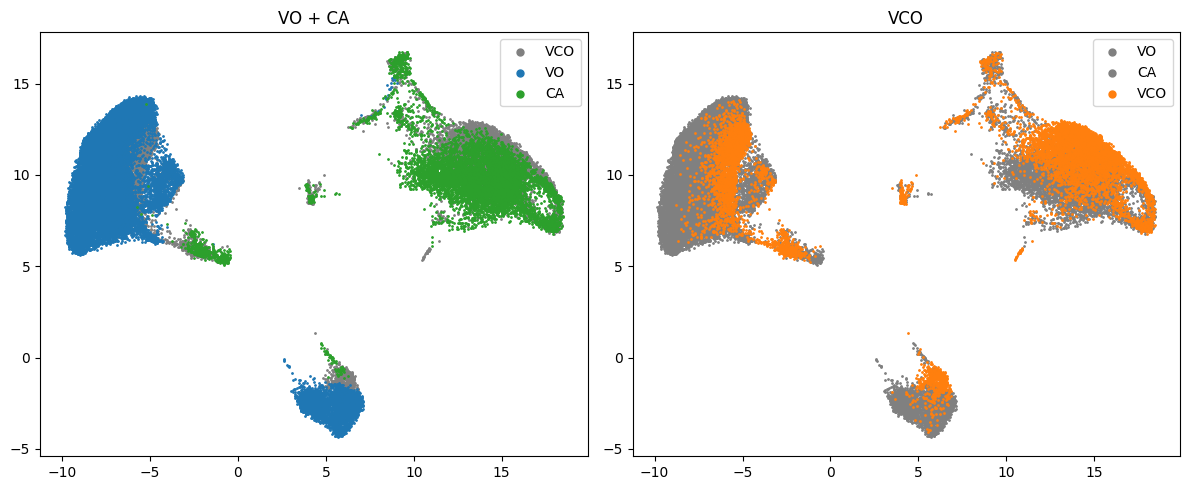

In [31]:
bc1 = "VO"
bc2 = "CA"
bc3 = "VCO"

adata_all = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_labelled/ALL.h5ad")
adata_vo = adata_all[adata_all.obs['batch'] == bc1]
adata_ho = adata_all[adata_all.obs['batch'] == bc2]
adata_vco = adata_all[adata_all.obs['batch'] == bc3]

fig, axs = plt.subplots(1, 2, figsize=(12,5))
colors = plt.get_cmap('tab10').colors

axs[0].scatter(adata_vco.obsm['X_umap'][:,0], adata_vco.obsm['X_umap'][:,1], color="grey", label=bc3, s=1)
axs[0].scatter(adata_vo.obsm['X_umap'][:,0], adata_vo.obsm['X_umap'][:,1], color=colors[0], label=bc1, s=1)
axs[0].scatter(adata_ho.obsm['X_umap'][:,0], adata_ho.obsm['X_umap'][:,1], color=colors[2], label=bc2, s=1)
axs[0].set_title(f"{bc1} + {bc2}")
axs[0].legend(markerscale=5)

axs[1].scatter(adata_vo.obsm['X_umap'][:,0], adata_vo.obsm['X_umap'][:,1], color="grey", label=bc1, s=1)
axs[1].scatter(adata_ho.obsm['X_umap'][:,0], adata_ho.obsm['X_umap'][:,1], color="grey", label=bc2, s=1)
axs[1].scatter(adata_vco.obsm['X_umap'][:,0], adata_vco.obsm['X_umap'][:,1], color=colors[1], label=bc3, s=1)
axs[1].set_title(bc3)
axs[1].legend(markerscale=5)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/umaps/{bc1}_{bc2}_{bc3}.complete.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/umaps/{bc1}_{bc2}_{bc3}.complete.svg', bbox_inches="tight")
plt.show()

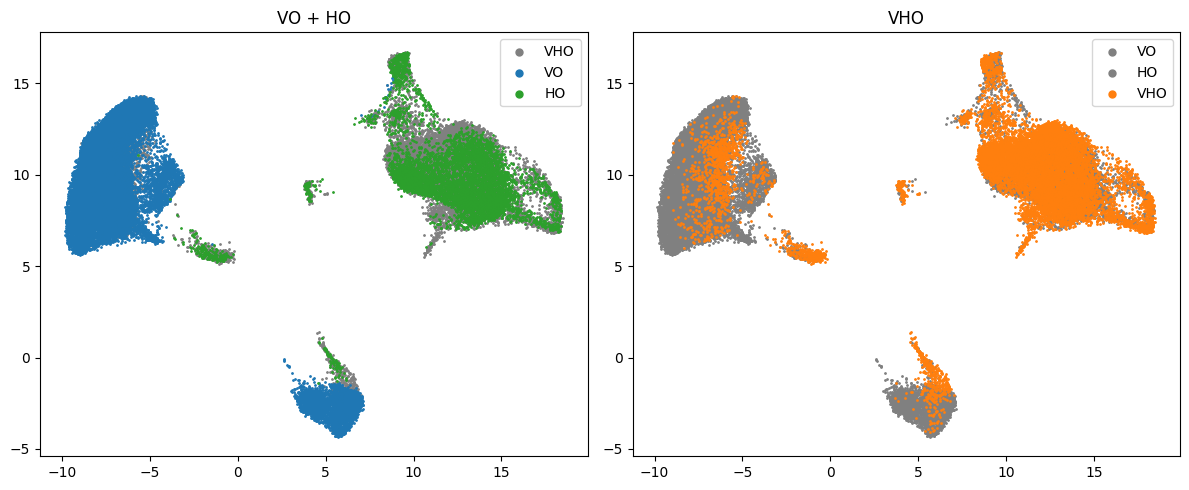

In [32]:
bc1 = "VO"
bc2 = "HO"
bc3 = "VHO"

adata_all = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_labelled/ALL.h5ad")
adata_vo = adata_all[adata_all.obs['batch'] == bc1]
adata_ho = adata_all[adata_all.obs['batch'] == bc2]
adata_vco = adata_all[adata_all.obs['batch'] == bc3]

fig, axs = plt.subplots(1, 2, figsize=(12,5))
colors = plt.get_cmap('tab10').colors

axs[0].scatter(adata_vco.obsm['X_umap'][:,0], adata_vco.obsm['X_umap'][:,1], color="grey", label=bc3, s=1)
axs[0].scatter(adata_vo.obsm['X_umap'][:,0], adata_vo.obsm['X_umap'][:,1], color=colors[0], label=bc1, s=1)
axs[0].scatter(adata_ho.obsm['X_umap'][:,0], adata_ho.obsm['X_umap'][:,1], color=colors[2], label=bc2, s=1)
axs[0].set_title(f"{bc1} + {bc2}")
axs[0].legend(markerscale=5)

axs[1].scatter(adata_vo.obsm['X_umap'][:,0], adata_vo.obsm['X_umap'][:,1], color="grey", label=bc1, s=1)
axs[1].scatter(adata_ho.obsm['X_umap'][:,0], adata_ho.obsm['X_umap'][:,1], color="grey", label=bc2, s=1)
axs[1].scatter(adata_vco.obsm['X_umap'][:,0], adata_vco.obsm['X_umap'][:,1], color=colors[1], label=bc3, s=1)
axs[1].set_title(bc3)
axs[1].legend(markerscale=5)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/umaps/{bc1}_{bc2}_{bc3}.complete.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/umaps/{bc1}_{bc2}_{bc3}.complete.svg', bbox_inches="tight")
plt.show()

# 2. Celltype split and recluster

In [4]:
%%bash
rm -r /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/adata/cell_type_split
rm -r /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/adata/cell_type_subclustered
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/adata/cell_type_split
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/adata/cell_type_subclustered

In [43]:
# os.system(f"mkdir -p {WORK_DIR}/distributions")

In [33]:
# cell_types = ['CM','PR','FB','SM','EP','EN','UN']
cell_types = ['CM','EC','EP','MU','UN']
samples = ['ALL','VO','HO','CA','VHO','VCO']
samples_old = ['ALL','BVO','HO','CM3O','BHO','CM3B']

MIN_CELL_COUNT = 10

In [34]:
adata_all = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_labelled/ALL.h5ad")
for ct in cell_types:
    adata = adata_all[adata_all.obs['cell_type'] == ct]
    adata.write_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")

## 2.1 cardiomyocyte

In [35]:
ct = "CM"

In [7]:
ct = "CM"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
sc.tl.leiden(adata, resolution=0.5, random_state=42)

adata.obs['leiden'] = adata.obs['leiden'].astype("int")
old_leiden = adata.obs['leiden'].unique()
old_leiden.sort()
for i, l in enumerate(old_leiden):
    adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i
adata.obs['leiden'] = adata.obs['leiden'].astype("str")
adata.obs['leiden'] = adata.obs['leiden'].astype("category")
adata.obs['leiden']

/tmp/ipykernel_3671672/386624598.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i


AAACCCAAGAAGGGAT-1-0    0
AAACCCAAGTCAGGGT-1-0    1
AAACCCACATCCAACA-1-0    1
AAACCCAGTAGATGTA-1-0    1
AAACCCAGTAGTACGG-1-0    1
                       ..
TTTGTTGAGACTGGGT-1-4    1
TTTGTTGAGATTGACA-1-4    0
TTTGTTGAGGGTACGT-1-4    0
TTTGTTGTCATGCCGG-1-4    3
TTTGTTGTCGTTGCCT-1-4    3
Name: leiden, Length: 25365, dtype: category
Categories (5, object): ['0', '1', '2', '3', '4']

In [8]:
ct = "CM"
adata = adata[adata.obs['leiden'] != "4"]
adata.obs['leiden']

AAACCCAAGAAGGGAT-1-0    0
AAACCCAAGTCAGGGT-1-0    1
AAACCCACATCCAACA-1-0    1
AAACCCAGTAGATGTA-1-0    1
AAACCCAGTAGTACGG-1-0    1
                       ..
TTTGTTGAGACTGGGT-1-4    1
TTTGTTGAGATTGACA-1-4    0
TTTGTTGAGGGTACGT-1-4    0
TTTGTTGTCATGCCGG-1-4    3
TTTGTTGTCGTTGCCT-1-4    3
Name: leiden, Length: 25229, dtype: category
Categories (4, object): ['0', '1', '2', '3']

In [18]:
adata.obs['cell_type_subcluster'] = adata.obs['leiden'].copy()
adata.obs['cell_type_subcluster'] = ct + "_" + (adata.obs['leiden'].astype('int') + 1).astype('str')
adata.obs['cell_type_subcluster'] = adata.obs['cell_type_subcluster'].astype('category')

adata.obs["cpdb_group"] = adata.obs['cell_type_subcluster'].copy()
adata.obs["cpdb_group"] = adata.obs["cpdb_group"].map({'CM_1': 'CM', 'CM_2': 'CM', 'CM_3': 'CM', 'CM_4': 'CM'})
adata.obs["cpdb_group"] = adata.obs["cpdb_group"].astype('category')

adata.write_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

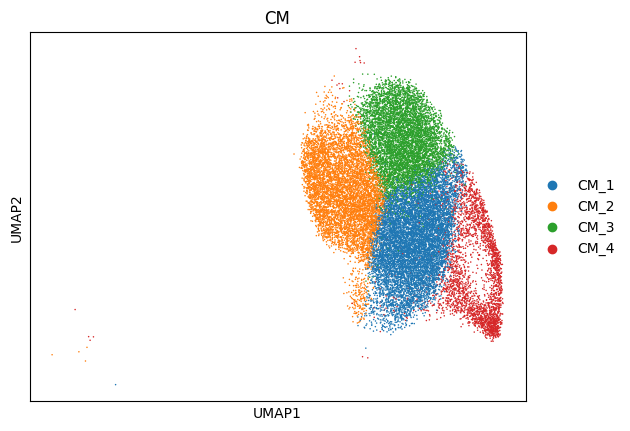

In [36]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")
sc.pl.umap(adata, color="cell_type_subcluster", title=f"{ct}")

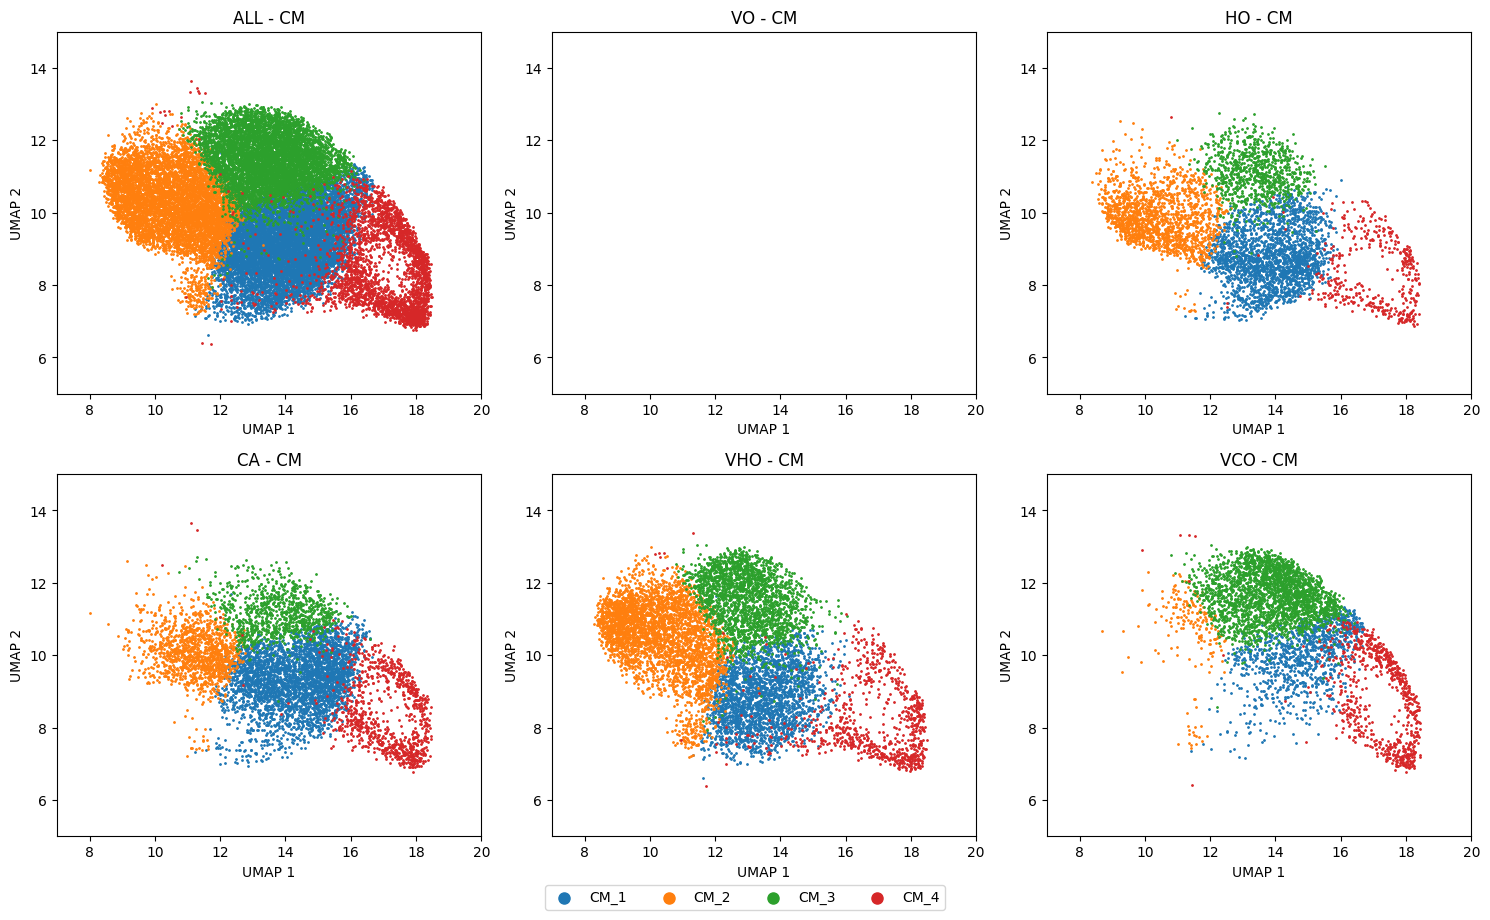

In [41]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

handles = []
labels = []

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for ctsc in adata.obs['cell_type_subcluster'].unique():
        adata_sub = adata_sample[adata_sample.obs['cell_type_subcluster'] == ctsc]
        sbplt = ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=ctsc, s=1)
        if j == 0:
            handles.append(sbplt)
            labels.append(ctsc)
    
    ax.set_xlim([7, 20])
    ax.set_ylim([5, 15])
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    # ax.legend(loc='upper right', markerscale=5, ncol=2)
    ax.set_title(f"{sample} - {ct}")

fig.legend(
    handles, labels,
    loc='lower center',
    ncol=4,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.025)
)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/umaps/secondary_leiden.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/umaps/secondary_leiden.{ct}.svg', bbox_inches="tight")
plt.show()

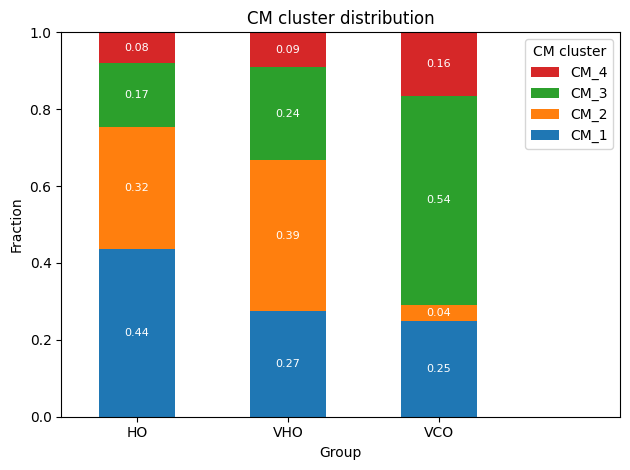

In [44]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL' or sample == 'CA' or sample == 'VO':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True)
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 3.2))
plt.xticks(rotation=0)
plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{ct} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distributions/secondary_leiden_woCA.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distributions/secondary_leiden_woCA.{ct}.svg', bbox_inches="tight")
plt.show()

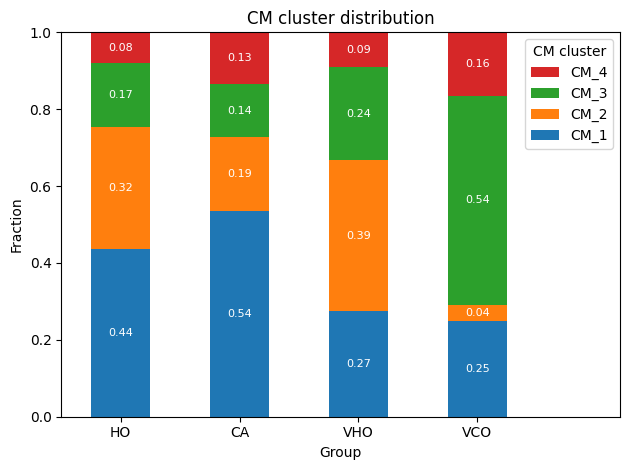

In [46]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL' or sample == 'VO':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True)
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 4.2))
plt.xticks(rotation=0)
plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{ct} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distributions/secondary_leiden_wCA.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distributions/secondary_leiden_wCA.{ct}.svg', bbox_inches="tight")
plt.show()

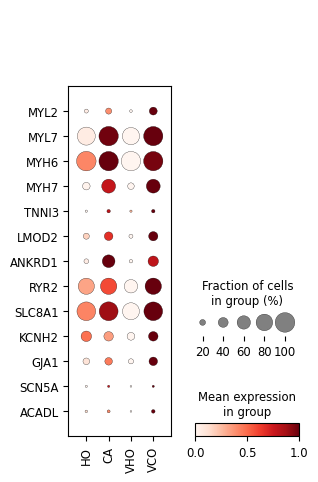

In [48]:
marker_dict = ['MYL2', 'MYL7', 'MYH6', 'MYH7', 'TNNI3', 'LMOD2', 'ANKRD1', 'RYR2', 'SLC8A1', 'KCNH2', 'GJA1', 'SCN5A', 'ACADL']
categories_order = ["HO", 'CA', 'VHO', 'VCO']

sc.pl.dotplot(adata, marker_dict, groupby="batch", standard_scale="var", show=False, swap_axes=True, categories_order=categories_order)
plt.savefig(f'{WORK_DIR}/dotplots/by_batch.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplots/by_batch.{ct}.svg', bbox_inches="tight")
plt.show()

In [51]:
adata.obs["cell_type_subcluster"]

AAACCCAAGAAGGGAT-1-0    CM_1
AAACCCAAGTCAGGGT-1-0    CM_2
AAACCCACATCCAACA-1-0    CM_2
AAACCCAGTAGATGTA-1-0    CM_2
AAACCCAGTAGTACGG-1-0    CM_2
                        ... 
TTTGTTGAGACTGGGT-1-4    CM_2
TTTGTTGAGATTGACA-1-4    CM_1
TTTGTTGAGGGTACGT-1-4    CM_1
TTTGTTGTCATGCCGG-1-4    CM_4
TTTGTTGTCGTTGCCT-1-4    CM_4
Name: cell_type_subcluster, Length: 25229, dtype: category
Categories (4, object): ['CM_1', 'CM_2', 'CM_3', 'CM_4']

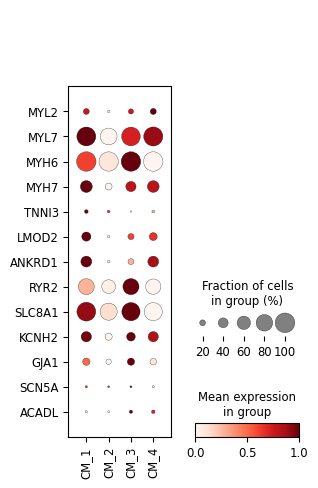

In [52]:
marker_dict = ['MYL2', 'MYL7', 'MYH6', 'MYH7', 'TNNI3', 'LMOD2', 'ANKRD1', 'RYR2', 'SLC8A1', 'KCNH2', 'GJA1', 'SCN5A', 'ACADL']
categories_order = ["HO", 'CA', 'VHO', 'VCO']

sc.pl.dotplot(adata, marker_dict, groupby="cell_type_subcluster", standard_scale="var", show=False, swap_axes=True)
plt.savefig(f'{WORK_DIR}/dotplots/by_cluster.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplots/by_cluster.{ct}.svg', bbox_inches="tight")
plt.show()

In [53]:
# marker_dict = [
#     "MYH7",
#     "MYL2",
#     "TNNI3",
#     "TNNT2",
#     "MYBPC3",
#     "TTN",
#     "ACTN2",
#     "RYR2",
#     "ATP2A2",
#     "PLN",
#     "SCN5A",
#     "KCNJ2",
#     "KCNH2",
#     "JPH2",
#     "BIN1",
#     "GJA1",
#     "PPARGC1A",
#     "PDK4",
#     "CPT1B",
#     "ACADVL",
#     "COX6A2",
#     "TFAM",
#     "HOPX",
#     "NUPR1",
#     "TRIB3",
#     "DDIT3",
#     "DDIT4",
#     "ASNS",
#     "PSAT1",
#     "SLC7A5",
#     "CHAC1",
#     "SLC7A11",
#     "HMOX1",
#     "PMAIP1",
#     "CASP9",
#     "INHBE",
#     "ADM2"
# ]

# sc.pl.dotplot(adata, marker_dict, groupby="cell_type_subcluster", swap_axes=True, title="CM subclusters")

In [54]:
# marker_dict = [
#     "MYH7",
#     "MYL2",
#     "TNNI3",
#     "TNNT2",
#     "MYBPC3",
#     "TTN",
#     "ACTN2",
#     "RYR2",
#     "ATP2A2",
#     "PLN",
#     "SCN5A",
#     "KCNJ2",
#     "KCNH2",
#     "JPH2",
#     "BIN1",
#     "GJA1",
#     "PPARGC1A",
#     "PDK4",
#     "CPT1B",
#     "ACADVL",
#     "COX6A2",
#     "TFAM",
#     "HOPX",
#     "NUPR1",
#     "TRIB3",
#     "DDIT3",
#     "DDIT4",
#     "ASNS",
#     "PSAT1",
#     "SLC7A5",
#     "CHAC1",
#     "SLC7A11",
#     "HMOX1",
#     "PMAIP1",
#     "CASP9",
#     "INHBE",
#     "ADM2"
# ]

# sc.pl.dotplot(adata, marker_dict, groupby="batch", categories_order=['HO','CA','VHO','VCO'], swap_axes=True, title="CM batch")

# adata_sub = adata[adata.obs["batch"] != 'CA']
# adata_sub = adata_sub[adata_sub.obs["batch"] != 'VHO']
# # sc.pl.dotplot(adata_sub, marker_dict, groupby="batch", categories_order=['HO','VCO'], standard_scale="var", swap_axes=True, title="CM batch")
# sc.pl.dotplot(adata_sub, marker_dict, groupby="batch", categories_order=['HO','VCO'], swap_axes=True, title="CM batch")

## 2.2 Endothelial cells

In [13]:
ct = "EC"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
sc.tl.leiden(adata, resolution=0.3, random_state=42)

adata.obs['leiden'] = adata.obs['leiden'].astype("int")
old_leiden = adata.obs['leiden'].unique()
old_leiden.sort()
for i, l in enumerate(old_leiden):
    adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i
adata.obs['leiden'] = adata.obs['leiden'].astype("str")
adata.obs['leiden'] = adata.obs['leiden'].astype("category")
adata.obs['leiden']

/tmp/ipykernel_3693479/2196373215.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i


AAACCCACATCCTTGC-1-0    2
AAAGAACAGGGCAATC-1-0    2
AAAGGATGTCAAGCGA-1-0    2
AAAGGGCCAGCGTATT-1-0    0
AAATGGAAGCTGCCAC-1-0    1
                       ..
TTAGGCAGTGTGTCGC-1-4    2
TTCGCTGCAAGTGGGT-1-4    2
TTTACTGGTAGACACG-1-4    2
TTTCAGTAGCGCTGAA-1-4    2
TTTGATCAGCGCACAA-1-4    2
Name: leiden, Length: 4160, dtype: category
Categories (3, object): ['0', '1', '2']

In [16]:
adata.obs['cell_type_subcluster'] = adata.obs['leiden'].copy()
adata.obs['cell_type_subcluster'] = ct + "_" + (adata.obs['leiden'].astype('int') + 1).astype('str')
# adata.obs["cell_type_subcluster"] = adata.obs["cell_type_subcluster"].map({'EN_0': 'EN_V', 'EN_1': 'EN_V', 'EN_2': 'EN_H'})
adata.obs['cell_type_subcluster'] = adata.obs['cell_type_subcluster'].astype('category')

adata.obs["cpdb_group"] = adata.obs['cell_type'].copy()
# adata.obs["cpdb_group"] = adata.obs["cpdb_group"].map({'EN_V': 'EN', 'EN_H': 'EN'})
adata.obs["cpdb_group"] = adata.obs["cpdb_group"].astype('category')

adata.write_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

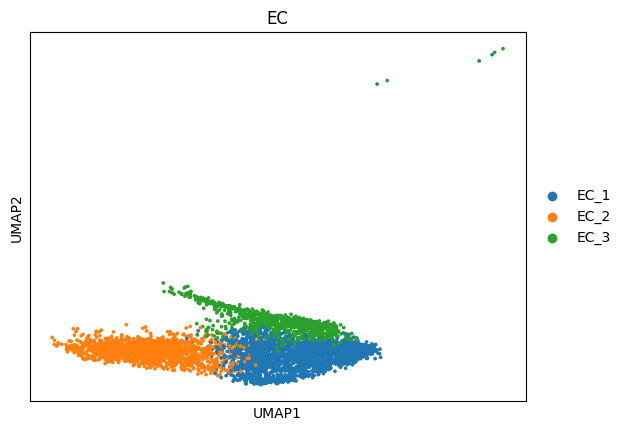

In [55]:
ct = "EC"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")
sc.pl.umap(adata, color="cell_type_subcluster", title=f"{ct}")

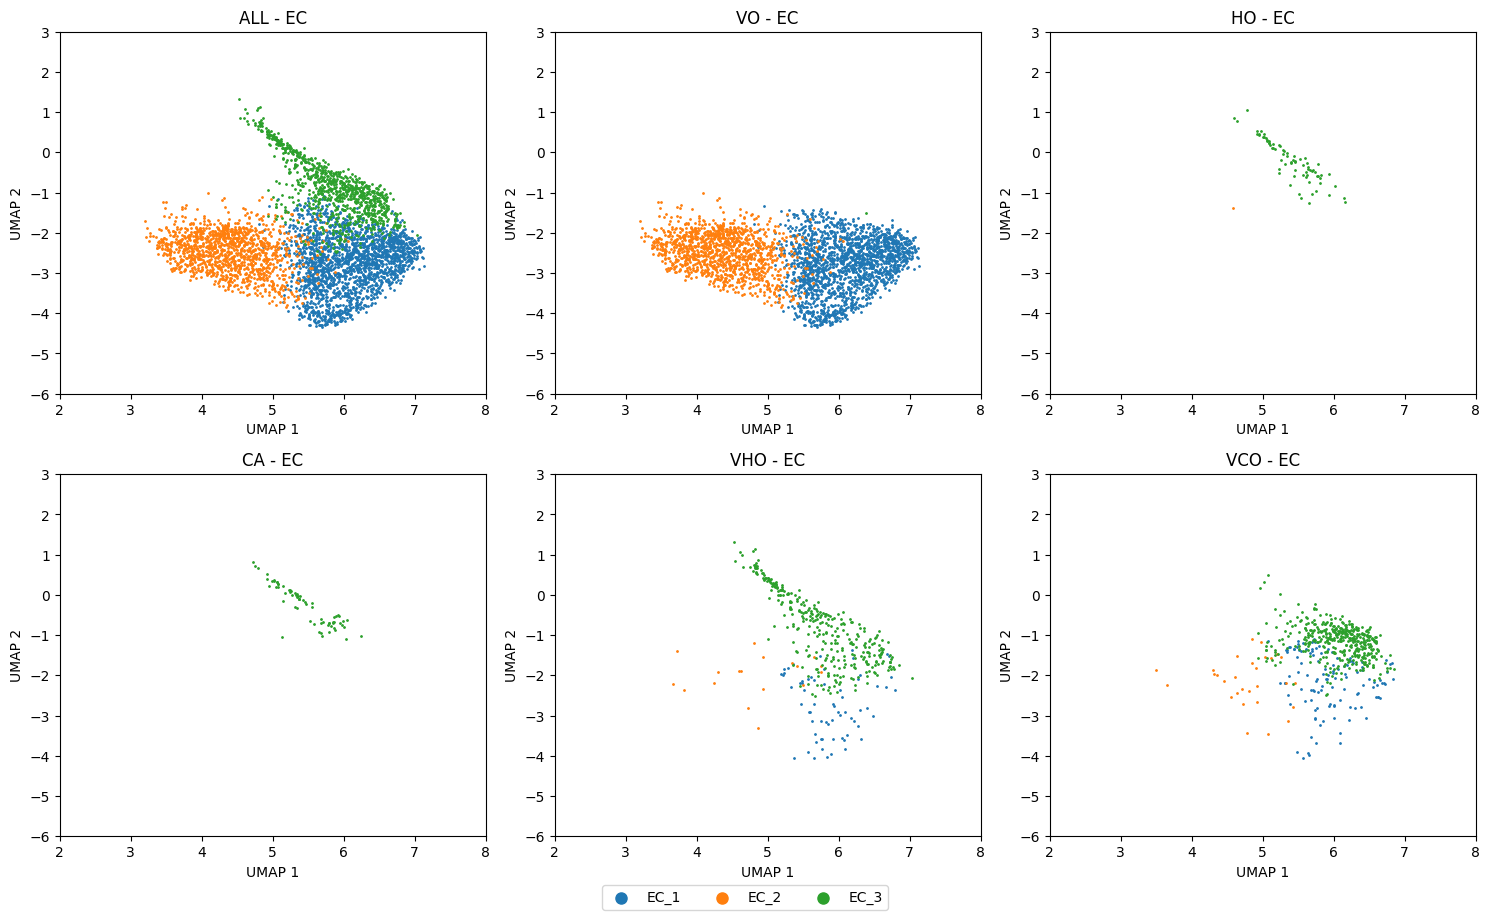

In [57]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

handles = []
labels = []

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for ctsc in adata.obs['cell_type_subcluster'].unique().sort_values():
        adata_sub = adata_sample[adata_sample.obs['cell_type_subcluster'] == ctsc]
        sbplt = ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=ctsc, s=1)
        if j == 0:
            handles.append(sbplt)
            labels.append(ctsc)
    
    ax.set_xlim([2, 8])
    ax.set_ylim([-6, 3])
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    # ax.legend(loc='upper right', markerscale=5, ncol=3)
    ax.set_title(f"{sample} - {ct}")

fig.legend(
    handles, labels,
    loc='lower center',
    ncol=4,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.025)
)
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/umaps/secondary_leiden.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/umaps/secondary_leiden.{ct}.svg', bbox_inches="tight")
plt.show()

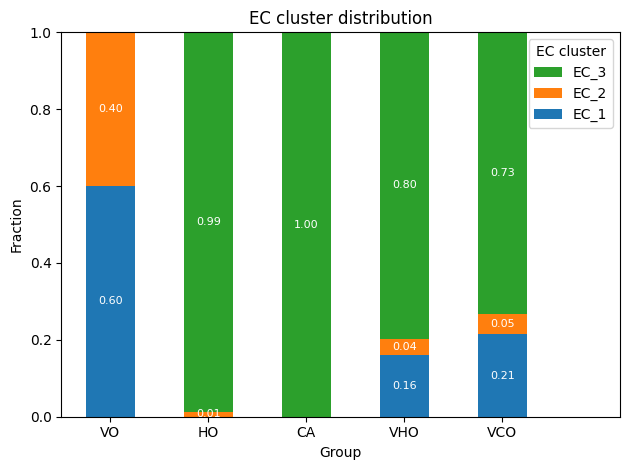

In [61]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True)
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 5.2))
plt.xticks(rotation=0)
plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{ct} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distributions/secondary_leiden_wCA.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distributions/secondary_leiden_wCA.{ct}.svg', bbox_inches="tight")
plt.show()

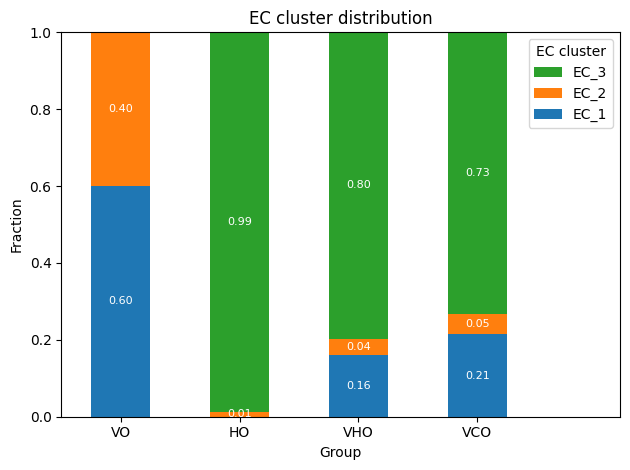

In [60]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL' or sample == "CA":
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True)
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 4.2))
plt.xticks(rotation=0)
plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{ct} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distributions/secondary_leiden_woCA.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distributions/secondary_leiden_woCA.{ct}.svg', bbox_inches="tight")
plt.show()

## 2.3 Mural cells

In [5]:
ct = "MU"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
sc.tl.leiden(adata, resolution=1, random_state=42)

adata.obs['leiden'] = adata.obs['leiden'].astype("int")
old_leiden = adata.obs['leiden'].unique()
old_leiden.sort()
for i, l in enumerate(old_leiden):
    adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i
adata.obs['leiden'] = adata.obs['leiden'].astype("str")
adata.obs['leiden'] = adata.obs['leiden'].astype("category")
adata.obs['leiden']

/tmp/ipykernel_2510932/3664054413.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata.obs['leiden'].loc[adata.obs['leiden'] == l] = i


AAACCCAAGTGGTCAG-1-0    3
AAACCCATCATTGCGA-1-0    5
AAACGAAAGAGCCGTA-1-0    2
AAACGAAAGGTCGTCC-1-0    8
AAAGAACAGCTCGCAC-1-0    3
                       ..
TTGGGTATCAGTGATC-1-4    8
TTTACGTGTCCGGCAT-1-4    8
TTTCCTCAGTCCTGCG-1-4    8
TTTGACTGTGGTAACG-1-4    8
TTTGTTGCAGCACAAG-1-4    8
Name: leiden, Length: 20095, dtype: category
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

In [11]:
adata.obs['cell_type_subcluster'] = adata.obs['leiden'].copy()
adata.obs['cell_type_subcluster'] = ct + "_" + adata.obs['cell_type_subcluster'].astype('str')
adata.obs['cell_type_subcluster'] = adata.obs['cell_type_subcluster'].map(
    {'MU_0': 'PR_1', 
     'MU_1': 'PR_2', 
     'MU_2': 'PR_3', 
     'MU_3': 'PR_4', 
     'MU_4': 'PR_5', 
     'MU_5': 'PR_6', 
     'MU_6': 'PR_7', 
     'MU_7': 'PR_8', 
     'MU_8': 'FB', 
     'MU_9': 'SM',}
)
adata.obs['cell_type_subcluster'] = adata.obs['cell_type_subcluster'].astype('category')

adata.obs["cpdb_group"] = adata.obs['cell_type_subcluster'].copy()
adata.obs["cpdb_group"] = adata.obs["cpdb_group"].map(
    {'PR_1': 'PR', 
     'PR_2': 'PR',
     'PR_3': 'PR', 
     'PR_4': 'PR', 
     'PR_5': 'PR', 
     'PR_6': 'PR', 
     'PR_7': 'PR', 
     'PR_8': 'PR', 
     'FB':   'FB', 
     'SM':   'SM'}
)
adata.obs["cpdb_group"] = adata.obs["cpdb_group"].astype('category')

adata.write_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

In [62]:
ct = "MU"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

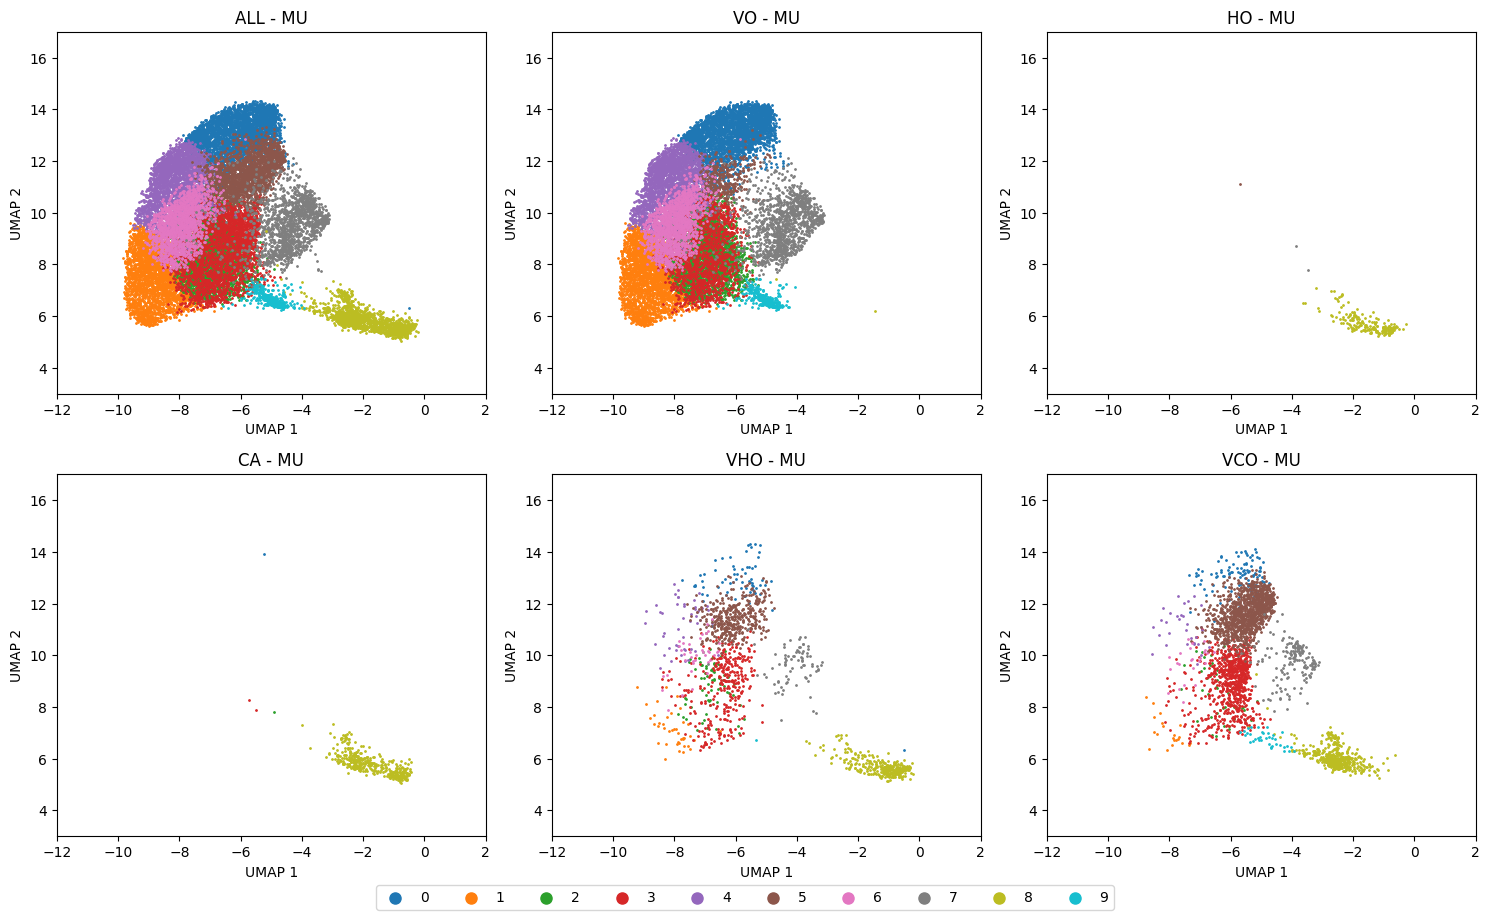

In [66]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

handles = []
labels = []

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for ctsc in adata.obs['leiden'].unique().sort_values():
        adata_sub = adata_sample[adata_sample.obs['leiden'] == ctsc]
        sbplt = ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=ctsc, s=1)
        if j == 0:
            handles.append(sbplt)
            labels.append(ctsc)
    
    ax.set_xlim([-12, 2])
    ax.set_ylim([3, 17])
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    # ax.legend(loc='upper right', markerscale=5, ncol=3)
    ax.set_title(f"{sample} - {ct}")

fig.legend(
    handles, labels,
    loc='lower center',
    ncol=10,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.025)
)
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/umaps/secondary_leiden.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/umaps/secondary_leiden.{ct}.svg', bbox_inches="tight")
plt.show()

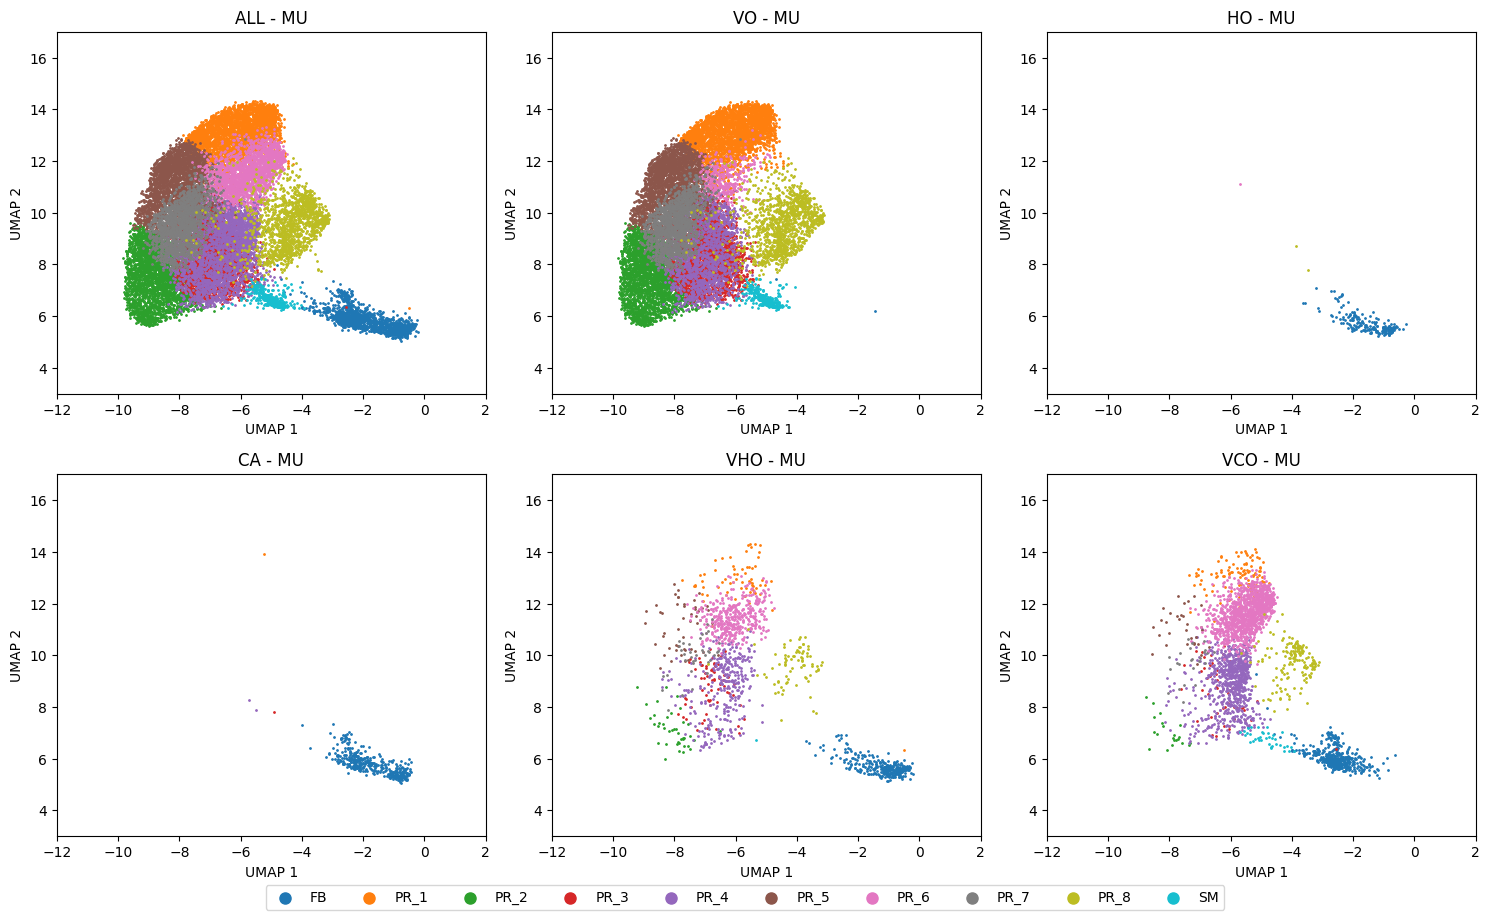

In [69]:
fig, axs = plt.subplots(2, 3, figsize=(15,9))
axs = axs.flatten()

handles = []
labels = []

for j, sample in enumerate(samples):
    
    ax = axs[j]
    
    if sample == 'ALL':
        adata_sample = adata
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        
    for ctsc in adata.obs['cell_type_subcluster'].unique().sort_values():
        adata_sub = adata_sample[adata_sample.obs['cell_type_subcluster'] == ctsc]
        sbplt = ax.scatter(adata_sub.obsm['X_umap'][:, 0], adata_sub.obsm['X_umap'][:, 1], label=ctsc, s=1)
        if j == 0:
            handles.append(sbplt)
            labels.append(ctsc)
    
    ax.set_xlim([-12, 2])
    ax.set_ylim([3, 17])
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    # ax.legend(loc='upper right', markerscale=5, ncol=3)
    ax.set_title(f"{sample} - {ct}")

fig.legend(
    handles, labels,
    loc='lower center',
    ncol=10,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.025)
)
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/umaps/secondary_label.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/umaps/secondary_label.{ct}.svg', bbox_inches="tight")
plt.show()

In [67]:
# marker_dict = ['CDH5', 'PECAM1', 'NOS3', 'VWF', 'CD34', 'ENG', 'FLT1', 'TEK', 'PDPN', 'MYH6', 
#                'MYH7', 'ACTC1', 'TNNT2', 'TNNI3', 'TNNI1', 'MYL2', 'MYL7', 'ACTA2', 'TAGLN', 'MYH11', 
#                'CNN1', 'DES', 'SMTN', 'VIM', 'CALD1', 'ELN', 'MYLK', 'S100A4', 'PDGFRA', 'THY1', 
#                'COL1A1', 'PDGFRB', 'CSPG4', 'RGS5', 'MCAM', 'NES', 'ITGB3', 'TGFBR1', 'TGFBR2', 'WT1', 
#                'TBX18', 'KRT8', 'KRT18', 'CDH1', 'EPCAM', 'SHH', 'RARA']

# sc.pl.dotplot(adata, marker_dict, groupby="cell_type_subcluster", standard_scale="var", swap_axes=True, title="FB + SM + PR")

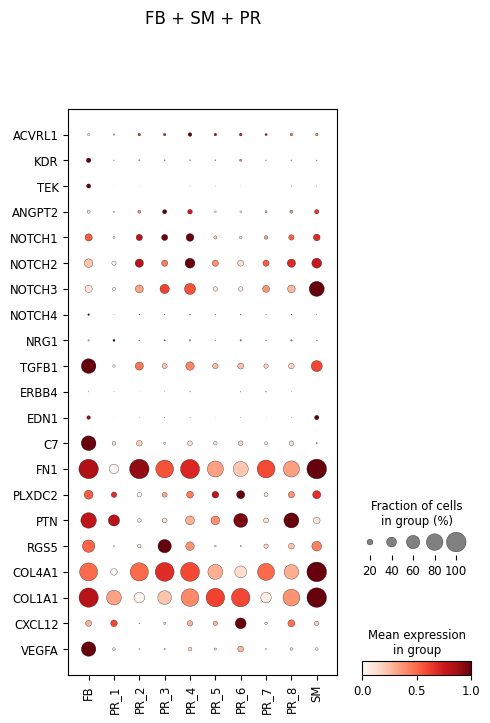

<Figure size 640x480 with 0 Axes>

In [70]:
marker_dict = ['ACVRL1', 'KDR', 'TEK', 'ANGPT2', 'NOTCH1', 
               'NOTCH2', 'NOTCH3', 'NOTCH4', 'NRG1', 'TGFB1', 
               'ERBB4', 'EDN1', 'C7', 'FN1', 'PLXDC2', 'PTN', 
               'RGS5', 'COL4A1', 'COL1A1', 'CXCL12', 'VEGFA']

sc.pl.dotplot(adata, marker_dict, groupby="cell_type_subcluster", standard_scale="var", swap_axes=True, title="FB + SM + PR")
plt.savefig(f'{WORK_DIR}/dotplots/by_cluster.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplots/by_cluster.{ct}.svg', bbox_inches="tight")
plt.show()

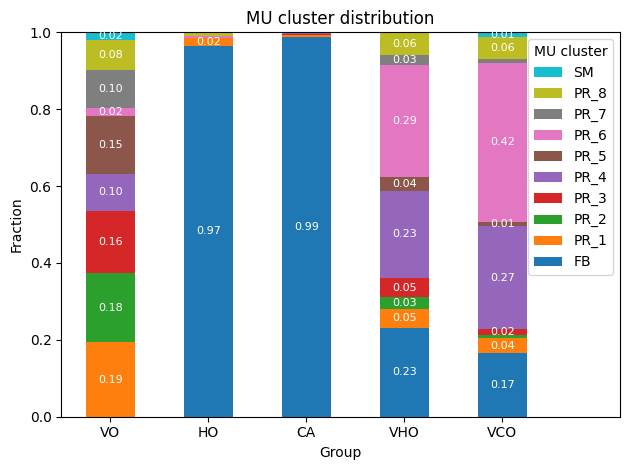

In [73]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True)
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 5.2))
plt.xticks(rotation=0)
plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{ct} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distributions/secondary_leiden_wCA.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distributions/secondary_leiden_wCA.{ct}.svg', bbox_inches="tight")
plt.show()

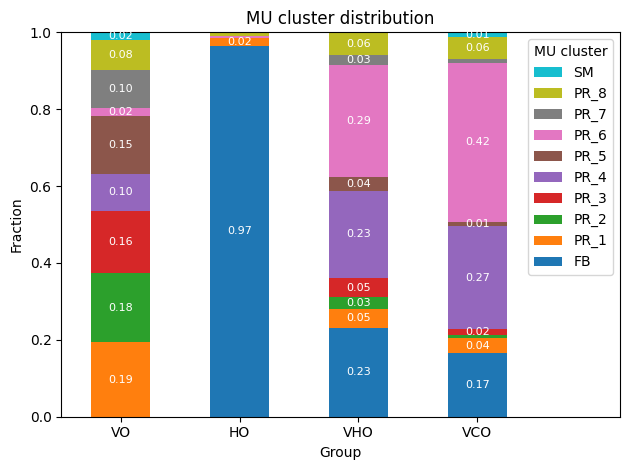

In [74]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL' or sample == "CA":
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True)
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 4.2))
plt.xticks(rotation=0)
plt.title(f"{ct} cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'{ct} cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distributions/secondary_leiden_woCA.{ct}.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distributions/secondary_leiden_woCA.{ct}.svg', bbox_inches="tight")
plt.show()

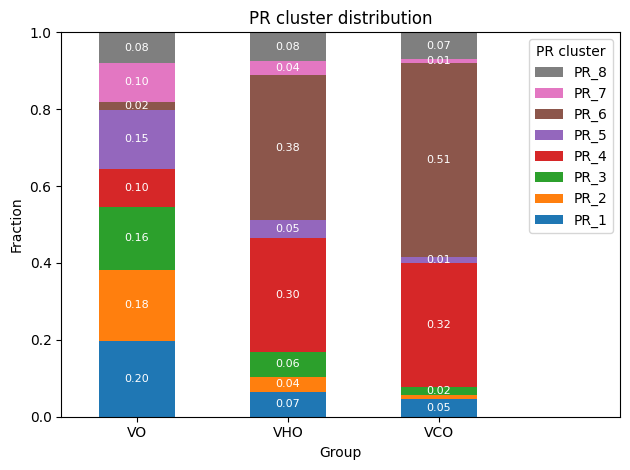

In [80]:
res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL' or sample == 'HO' or sample == 'CA':
        continue
    else:
        adata_sample = adata[adata.obs['batch'] == sample]
        res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
        res_col.append(sample)
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.drop('FB', axis=1)
df = df.drop('SM', axis=1)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True)
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 3.2))
plt.xticks(rotation=0)
plt.title(f"PR cluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title=f'PR cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distributions/secondary_leiden.PR.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distributions/secondary_leiden.PR.svg', bbox_inches="tight")
plt.show()

In [75]:
# res = []
# res_col = []

# for j, sample in enumerate(samples):    
#     if sample == 'ALL' or sample == 'CA' or sample == 'HO':
#         continue
#     else:
#         adata_sample = adata[adata.obs['batch'] == sample]
#         res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
#         res_col.append(sample)
        
# for r in res:
#     r[r < MIN_CELL_COUNT] = 0
        
# all_categories = sorted(set().union(*[s.index for s in res]))
# aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
# df = pd.DataFrame(aligned_series, index=res_col)
# df = df.drop('FB', axis=1)
# df = df.T
# df = np.divide(df, df.sum())
# df = df.T

# ax = df.plot(kind='bar', stacked=True)
# plt.xlabel('Group')
# plt.ylabel('Fraction')
# plt.ylim((0, 1))
# plt.xlim((-0.5, 3.2))
# plt.xticks(rotation=0)
# plt.title("Mural cells cluster distribution")

# # Reverse legend to match stack order
# handles, labels = ax.get_legend_handles_labels()
# ax.legend(handles[::-1], labels[::-1], title=f'{ct} cluster')

# # Add fraction labels
# for bar in ax.containers:
#     for rect in bar:
#         height = rect.get_height()
#         if height > 0.01:  # Avoid cluttering small segments
#             ax.text(
#                 rect.get_x() + rect.get_width() / 2,
#                 rect.get_y() + height / 2,
#                 f'{height:.2f}',
#                 ha='center', va='center', fontsize=8, color='white'
#             )

# plt.tight_layout()
# plt.savefig(f'{WORK_DIR}/distributions/secondary_leiden_woCA.{ct}.png', bbox_inches="tight")
# plt.savefig(f'{WORK_DIR}/distributions/secondary_leiden_woCA.{ct}.svg', bbox_inches="tight")
# plt.show()

In [76]:
# res = []
# res_col = []

# for j, sample in enumerate(samples):    
#     if sample == 'ALL' or sample == 'CA':
#         continue
#     else:
#         adata_sample = adata[adata.obs['batch'] == sample]
#         res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
#         res_col.append(sample)
        
# for r in res:
#     r[r < MIN_CELL_COUNT] = 0
        
# all_categories = sorted(set().union(*[s.index for s in res]))
# aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
# df = pd.DataFrame(aligned_series, index=res_col)
# df = df.T
# df = np.divide(df, df.sum())
# df = df.T

# ax = df.plot(kind='bar', stacked=True)
# plt.xlabel('Group')
# plt.ylabel('Fraction')
# plt.ylim((0, 1))
# plt.xlim((-0.5, 4.2))
# plt.xticks(rotation=0)
# plt.title("Mural cells cluster distribution")

# # Reverse legend to match stack order
# handles, labels = ax.get_legend_handles_labels()
# ax.legend(handles[::-1], labels[::-1], title='MU cluster')

# # Add fraction labels
# for bar in ax.containers:
#     for rect in bar:
#         height = rect.get_height()
#         if height > 0.01:  # Avoid cluttering small segments
#             ax.text(
#                 rect.get_x() + rect.get_width() / 2,
#                 rect.get_y() + height / 2,
#                 f'{height:.2f}',
#                 ha='center', va='center', fontsize=8, color='white'
#             )

# plt.tight_layout()
# plt.show()

In [77]:
# res = []
# res_col = []

# for j, sample in enumerate(samples):    
#     if sample == 'ALL':
#         continue
#     else:
#         adata_sample = adata[adata.obs['batch'] == sample]
#         res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
#         res_col.append(sample)
        
# for r in res:
#     r[r < MIN_CELL_COUNT] = 0
        
# all_categories = sorted(set().union(*[s.index for s in res]))
# aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
# df = pd.DataFrame(aligned_series, index=res_col)
# df = df.T
# df = np.divide(df, df.sum())
# df = df.T

# ax = df.plot(kind='bar', stacked=True)
# plt.xlabel('Group')
# plt.ylabel('Fraction')
# plt.ylim((0, 1))
# plt.xlim((-0.5, 5.2))
# plt.xticks(rotation=0)
# plt.title("Mural cells cluster distribution")

# # Reverse legend to match stack order
# handles, labels = ax.get_legend_handles_labels()
# ax.legend(handles[::-1], labels[::-1], title='MU cluster')

# # Add fraction labels
# for bar in ax.containers:
#     for rect in bar:
#         height = rect.get_height()
#         if height > 0.01:  # Avoid cluttering small segments
#             ax.text(
#                 rect.get_x() + rect.get_width() / 2,
#                 rect.get_y() + height / 2,
#                 f'{height:.2f}',
#                 ha='center', va='center', fontsize=8, color='white'
#             )

# plt.tight_layout()
# plt.show()

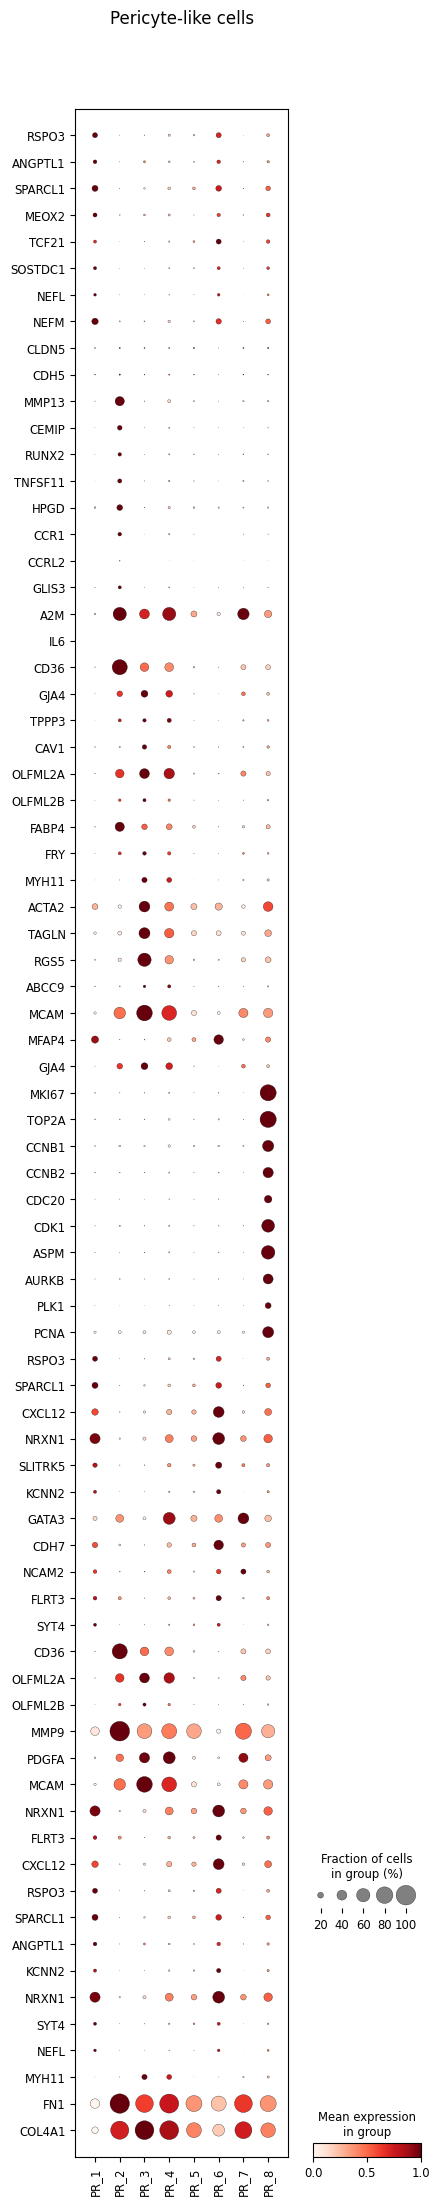

In [82]:
ct = "MU"
adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")
adata = adata[adata.obs['cpdb_group'] == 'PR']

marker_str = "RSPO3, ANGPTL1, SPARCL1, MEOX2, TCF21, SOSTDC1, NEFL, NEFM, CLDN5, CDH5, MMP13, CEMIP, RUNX2, TNFSF11, HPGD, CCR1, CCRL2, GLIS3, A2M, IL6, CD36, GJA4, TPPP3, CAV1, OLFML2A, OLFML2B, FABP4, FRY,  MYH11, ACTA2, TAGLN, RGS5, ABCC9, MCAM, MFAP4, GJA4, MKI67, TOP2A, CCNB1, CCNB2, CDC20, CDK1, ASPM, AURKB, PLK1, PCNA,  RSPO3, SPARCL1, CXCL12, NRXN1, SLITRK5, KCNN2, GATA3, CDH7, NCAM2, FLRT3, SYT4, CD36, OLFML2A, OLFML2B, MMP9, PDGFA, MCAM, NRXN1, FLRT3, CXCL12,  RSPO3, SPARCL1, ANGPTL1, KCNN2, NRXN1, SYT4, NEFL, MYH11, FN1, COL4A1"
marker_dict = marker_str.replace(" ", "").split(",")

sc.pl.dotplot(adata, marker_dict, groupby="cell_type_subcluster", standard_scale="var", swap_axes=True, title="Pericyte-like cells", show=False)
plt.savefig(f'{WORK_DIR}/dotplots/by_cluster.PR.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/dotplots/by_cluster.PR.svg', bbox_inches="tight")
plt.show()

## 2.4 Epithelial cells and Unknowns

In [37]:
# cts = ['PR','EP','UN']
cts = ['EP','UN']

for ct in cts:
    adata = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_split/{ct}.h5ad")
    adata.obs['cell_type_subcluster'] = adata.obs['cell_type'].copy()
    adata.obs['cpdb_group'] = adata.obs['cell_type'].copy()
    adata.write_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")

## 2.5 recollect

In [25]:
%%bash
rm -r /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/adata/sample_recollect
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/adata/sample_recollect

In [5]:
cell_type_subcluster = []
cpdb_group = []

for sample in ['ALL','VO','HO','CA','VHO','VCO']:
    # for ct in ['CM','PR','FB','SM','EP','EN','UN']:
    adata_sample = None
    for ct in ['CM','EC','MU','EP','UN']:
        
        adata_ct = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")
        
        if sample == 'ALL':
            adata_ct_sample = adata_ct
            cell_type_subcluster = cell_type_subcluster + adata_ct.obs['cell_type_subcluster'].unique().to_list()
            cell_type_subcluster.sort()
            cpdb_group = cpdb_group + adata_ct.obs['cpdb_group'].unique().to_list()
            cpdb_group.sort()
        else:
            adata_ct_sample = adata_ct[adata_ct.obs['batch'] == sample]
            
        group_counts = adata_ct_sample.obs["cpdb_group"].value_counts()
        valid_groups = group_counts[group_counts >= MIN_CELL_COUNT].index
        adata_ct_sample_filtered = adata_ct_sample[adata_ct_sample.obs["cpdb_group"].isin(valid_groups)].copy()

        if adata_sample is None:
            adata_sample = adata_ct_sample_filtered
        else:
            adata_sample = ad.concat([adata_sample, adata_ct_sample_filtered], join='inner', axis=0)
            
    adata_sample.write_h5ad(f"{WORK_DIR}/adata/sample_recollect/{sample}.h5ad")

In [84]:
cell_type_subcluster = []
cpdb_group = []

for sample in ['ALL','VO','HO','CA','VHO','VCO']:
    # for ct in ['CM','PR','FB','SM','EP','EN','UN']:
    adata_sample = None
    for ct in ['CM','EC','MU','EP','UN']:
        
        adata_ct = sc.read_h5ad(f"{WORK_DIR}/adata/cell_type_subclustered/{ct}.h5ad")
        
        if sample == 'ALL':
            adata_ct_sample = adata_ct
            cell_type_subcluster = cell_type_subcluster + adata_ct.obs['cell_type_subcluster'].unique().to_list()
            cell_type_subcluster.sort()
            cpdb_group = cpdb_group + adata_ct.obs['cpdb_group'].unique().to_list()
            cpdb_group.sort()
        else:
            adata_ct_sample = adata_ct[adata_ct.obs['batch'] == sample]
            
        group_counts = adata_ct_sample.obs["cpdb_group"].value_counts()
        valid_groups = group_counts[group_counts >= MIN_CELL_COUNT].index
        adata_ct_sample_filtered = adata_ct_sample[adata_ct_sample.obs["cpdb_group"].isin(valid_groups)].copy()

        if adata_sample is None:
            adata_sample = adata_ct_sample_filtered
        else:
            adata_sample = ad.concat([adata_sample, adata_ct_sample_filtered], join='inner', axis=0)

## 2.6 visualization

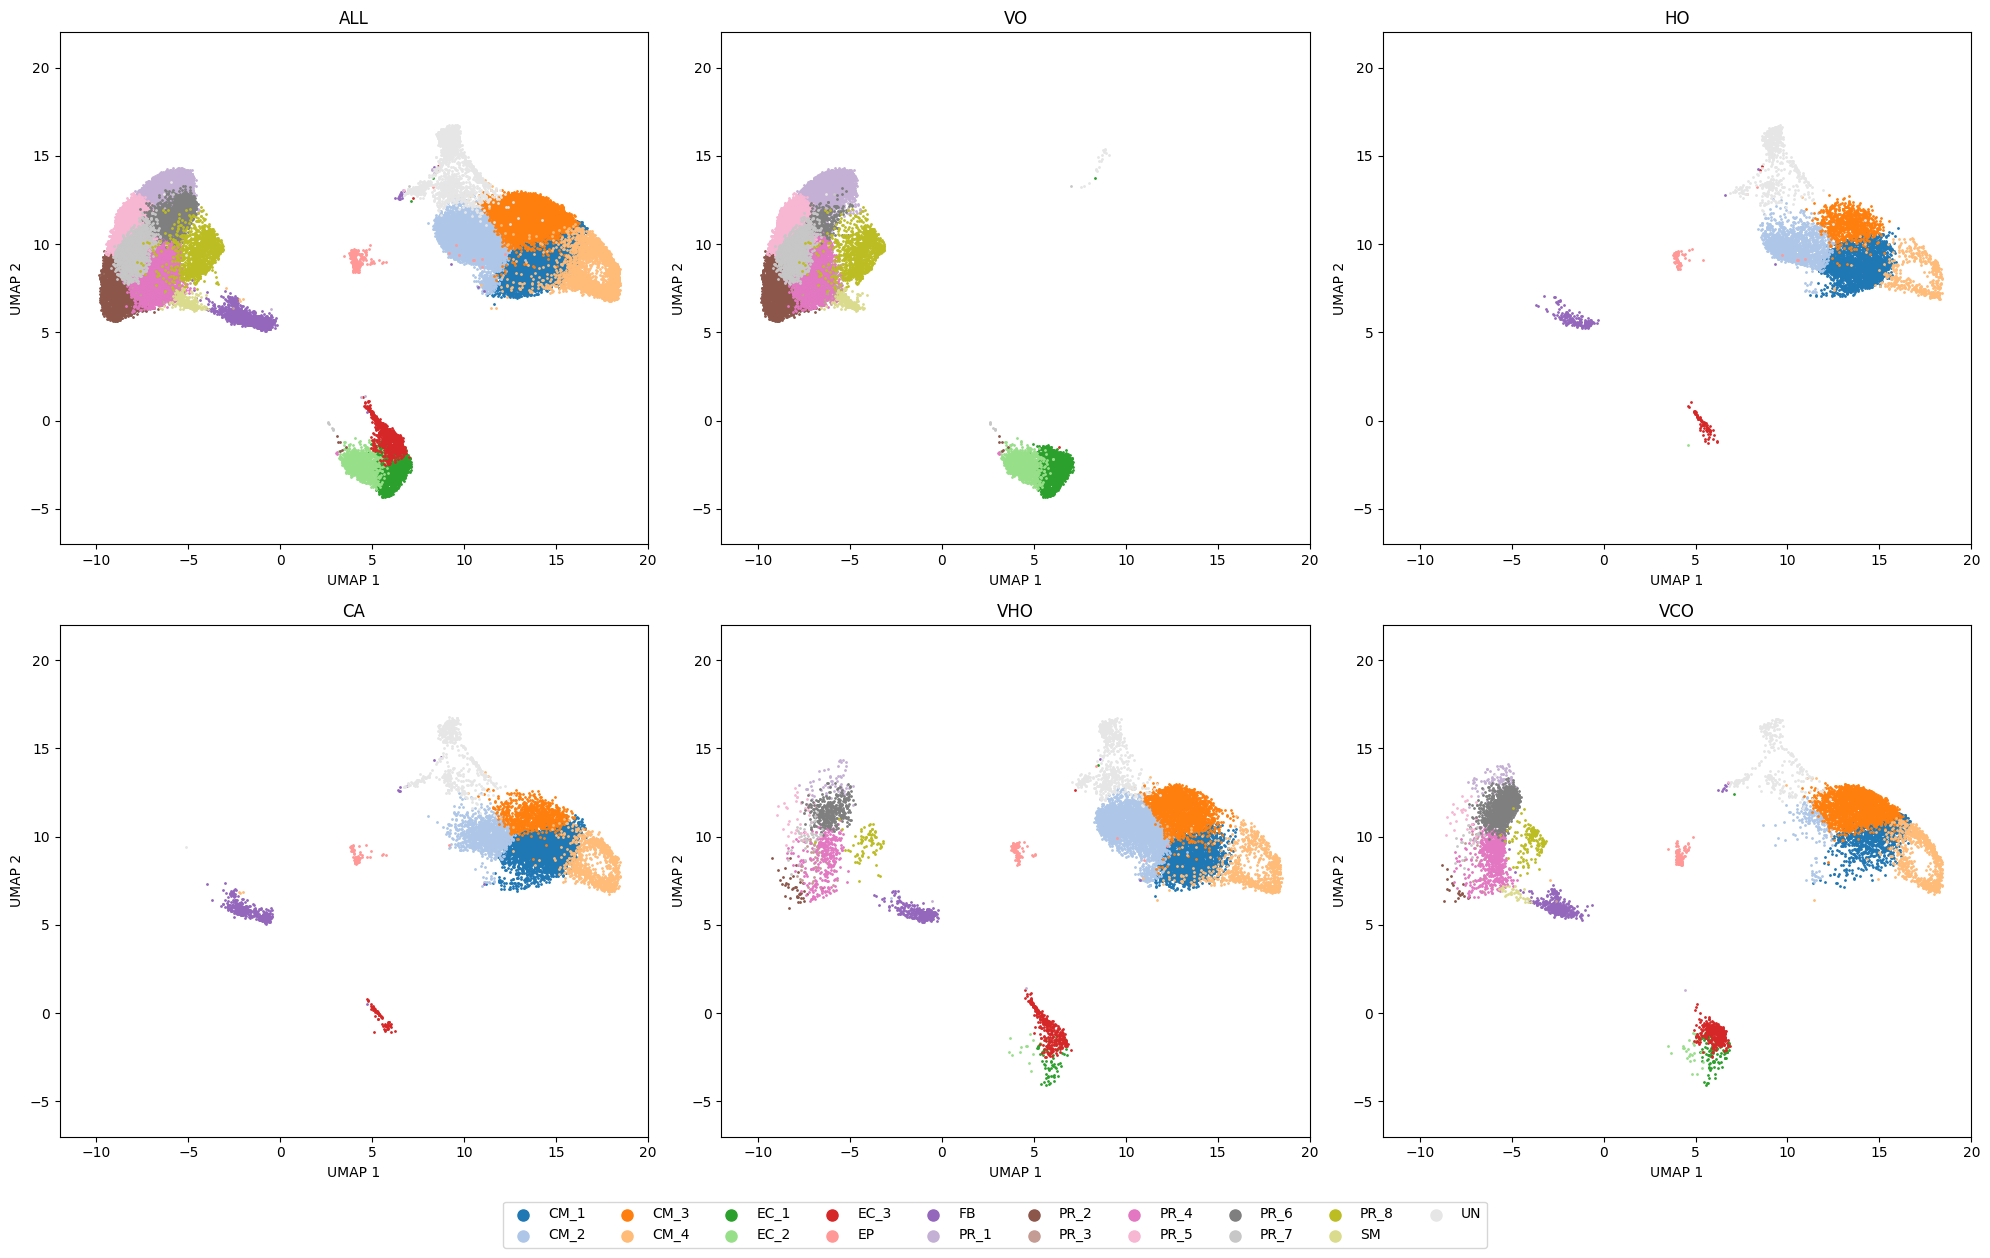

In [85]:
colordict1 = {}

fig, axs = plt.subplots(2, 3, figsize=(20,12))
axs = axs.flatten()

cmap = plt.get_cmap('viridis')
colors = plt.get_cmap('tab20').colors

batch_mapper = dict(zip(samples_old, samples))

handles = []
labels = []

for i, sample in enumerate(samples):
    
    adata = sc.read_h5ad(f'{WORK_DIR}/adata/sample_recollect/{sample}.h5ad')
    
    for j, cts in enumerate(cell_type_subcluster):
        if cts != 'UN':
            color = colors[j]
        else:
            color = (0.9, 0.9, 0.9)
        sc_plot = axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['cell_type_subcluster'] == cts, 0], 
            adata.obsm['X_umap'][adata.obs['cell_type_subcluster'] == cts, 1], 
            label=cts, 
            color=color, s=1)
        
        colordict1[cts] = color
        
        if i == 0:
            handles.append(sc_plot)
            labels.append(cts)
        
    # axs[i].legend(loc='upper left', markerscale=8, ncol=5)
    axs[i].set_xlabel('UMAP 1')
    axs[i].set_ylabel('UMAP 2')
    axs[i].set_title(sample)
    axs[i].set_xlim([-12, 20])
    axs[i].set_ylim([-7, 22])

fig.legend(
    handles, labels,
    loc='lower center',
    ncol=10,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.05)  # tweak Y if needed
)
    
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/umaps/secondary_label.complete.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/umaps/secondary_label.complete.svg', bbox_inches="tight")
plt.show()

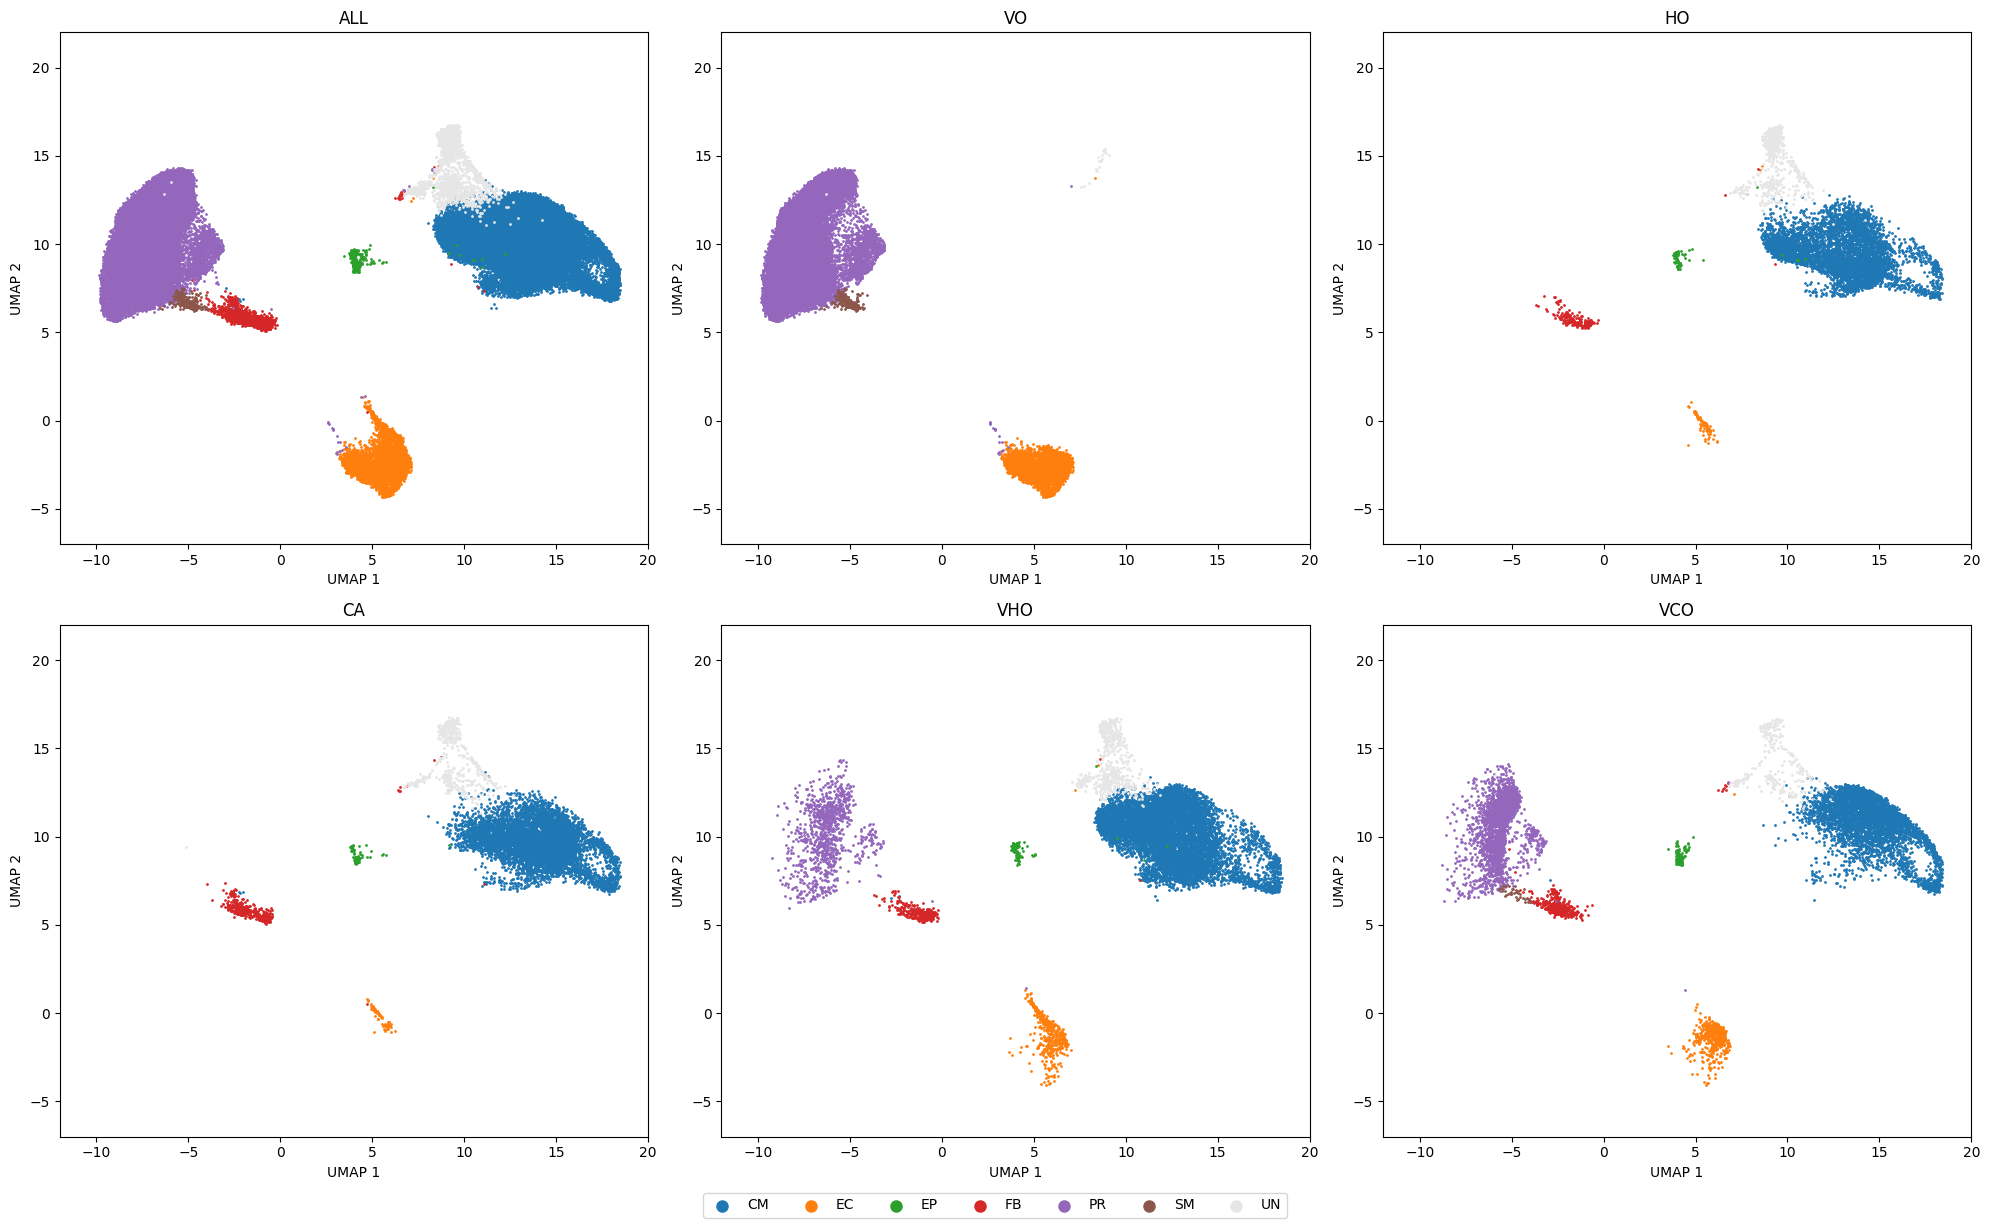

In [86]:
colordict2 = {}

fig, axs = plt.subplots(2, 3, figsize=(20,12))
axs = axs.flatten()

cmap = plt.get_cmap('viridis')
colors = plt.get_cmap('tab10').colors

batch_mapper = dict(zip(samples_old, samples))

handles = []
labels = []

for i, sample in enumerate(samples):
    
    adata = sc.read_h5ad(f'{WORK_DIR}/adata/sample_recollect/{sample}.h5ad')
    
    for j, cts in enumerate(cpdb_group):
        if cts != 'UN':
            color = colors[j]
        else:
            color = (0.9, 0.9, 0.9)
        sc_plot = axs[i].scatter(
            adata.obsm['X_umap'][adata.obs['cpdb_group'] == cts, 0], 
            adata.obsm['X_umap'][adata.obs['cpdb_group'] == cts, 1], 
            label=cts, 
            color=color, s=1)

        colordict2[cts] = color

        if i == 0:
            handles.append(sc_plot)
            labels.append(cts)
        
    # axs[i].legend(loc='upper left', markerscale=8, ncol=5)
    axs[i].set_xlabel('UMAP 1')
    axs[i].set_ylabel('UMAP 2')
    axs[i].set_title(sample)
    axs[i].set_xlim([-12, 20])
    axs[i].set_ylim([-7, 22])

fig.legend(
    handles, labels,
    loc='lower center',
    ncol=7,
    markerscale=8,
    bbox_to_anchor=(0.5, -0.025)  # tweak Y if needed
)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/umaps/cpdb_group.complete.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/umaps/cpdb_group.complete.svg', bbox_inches="tight")
plt.show()

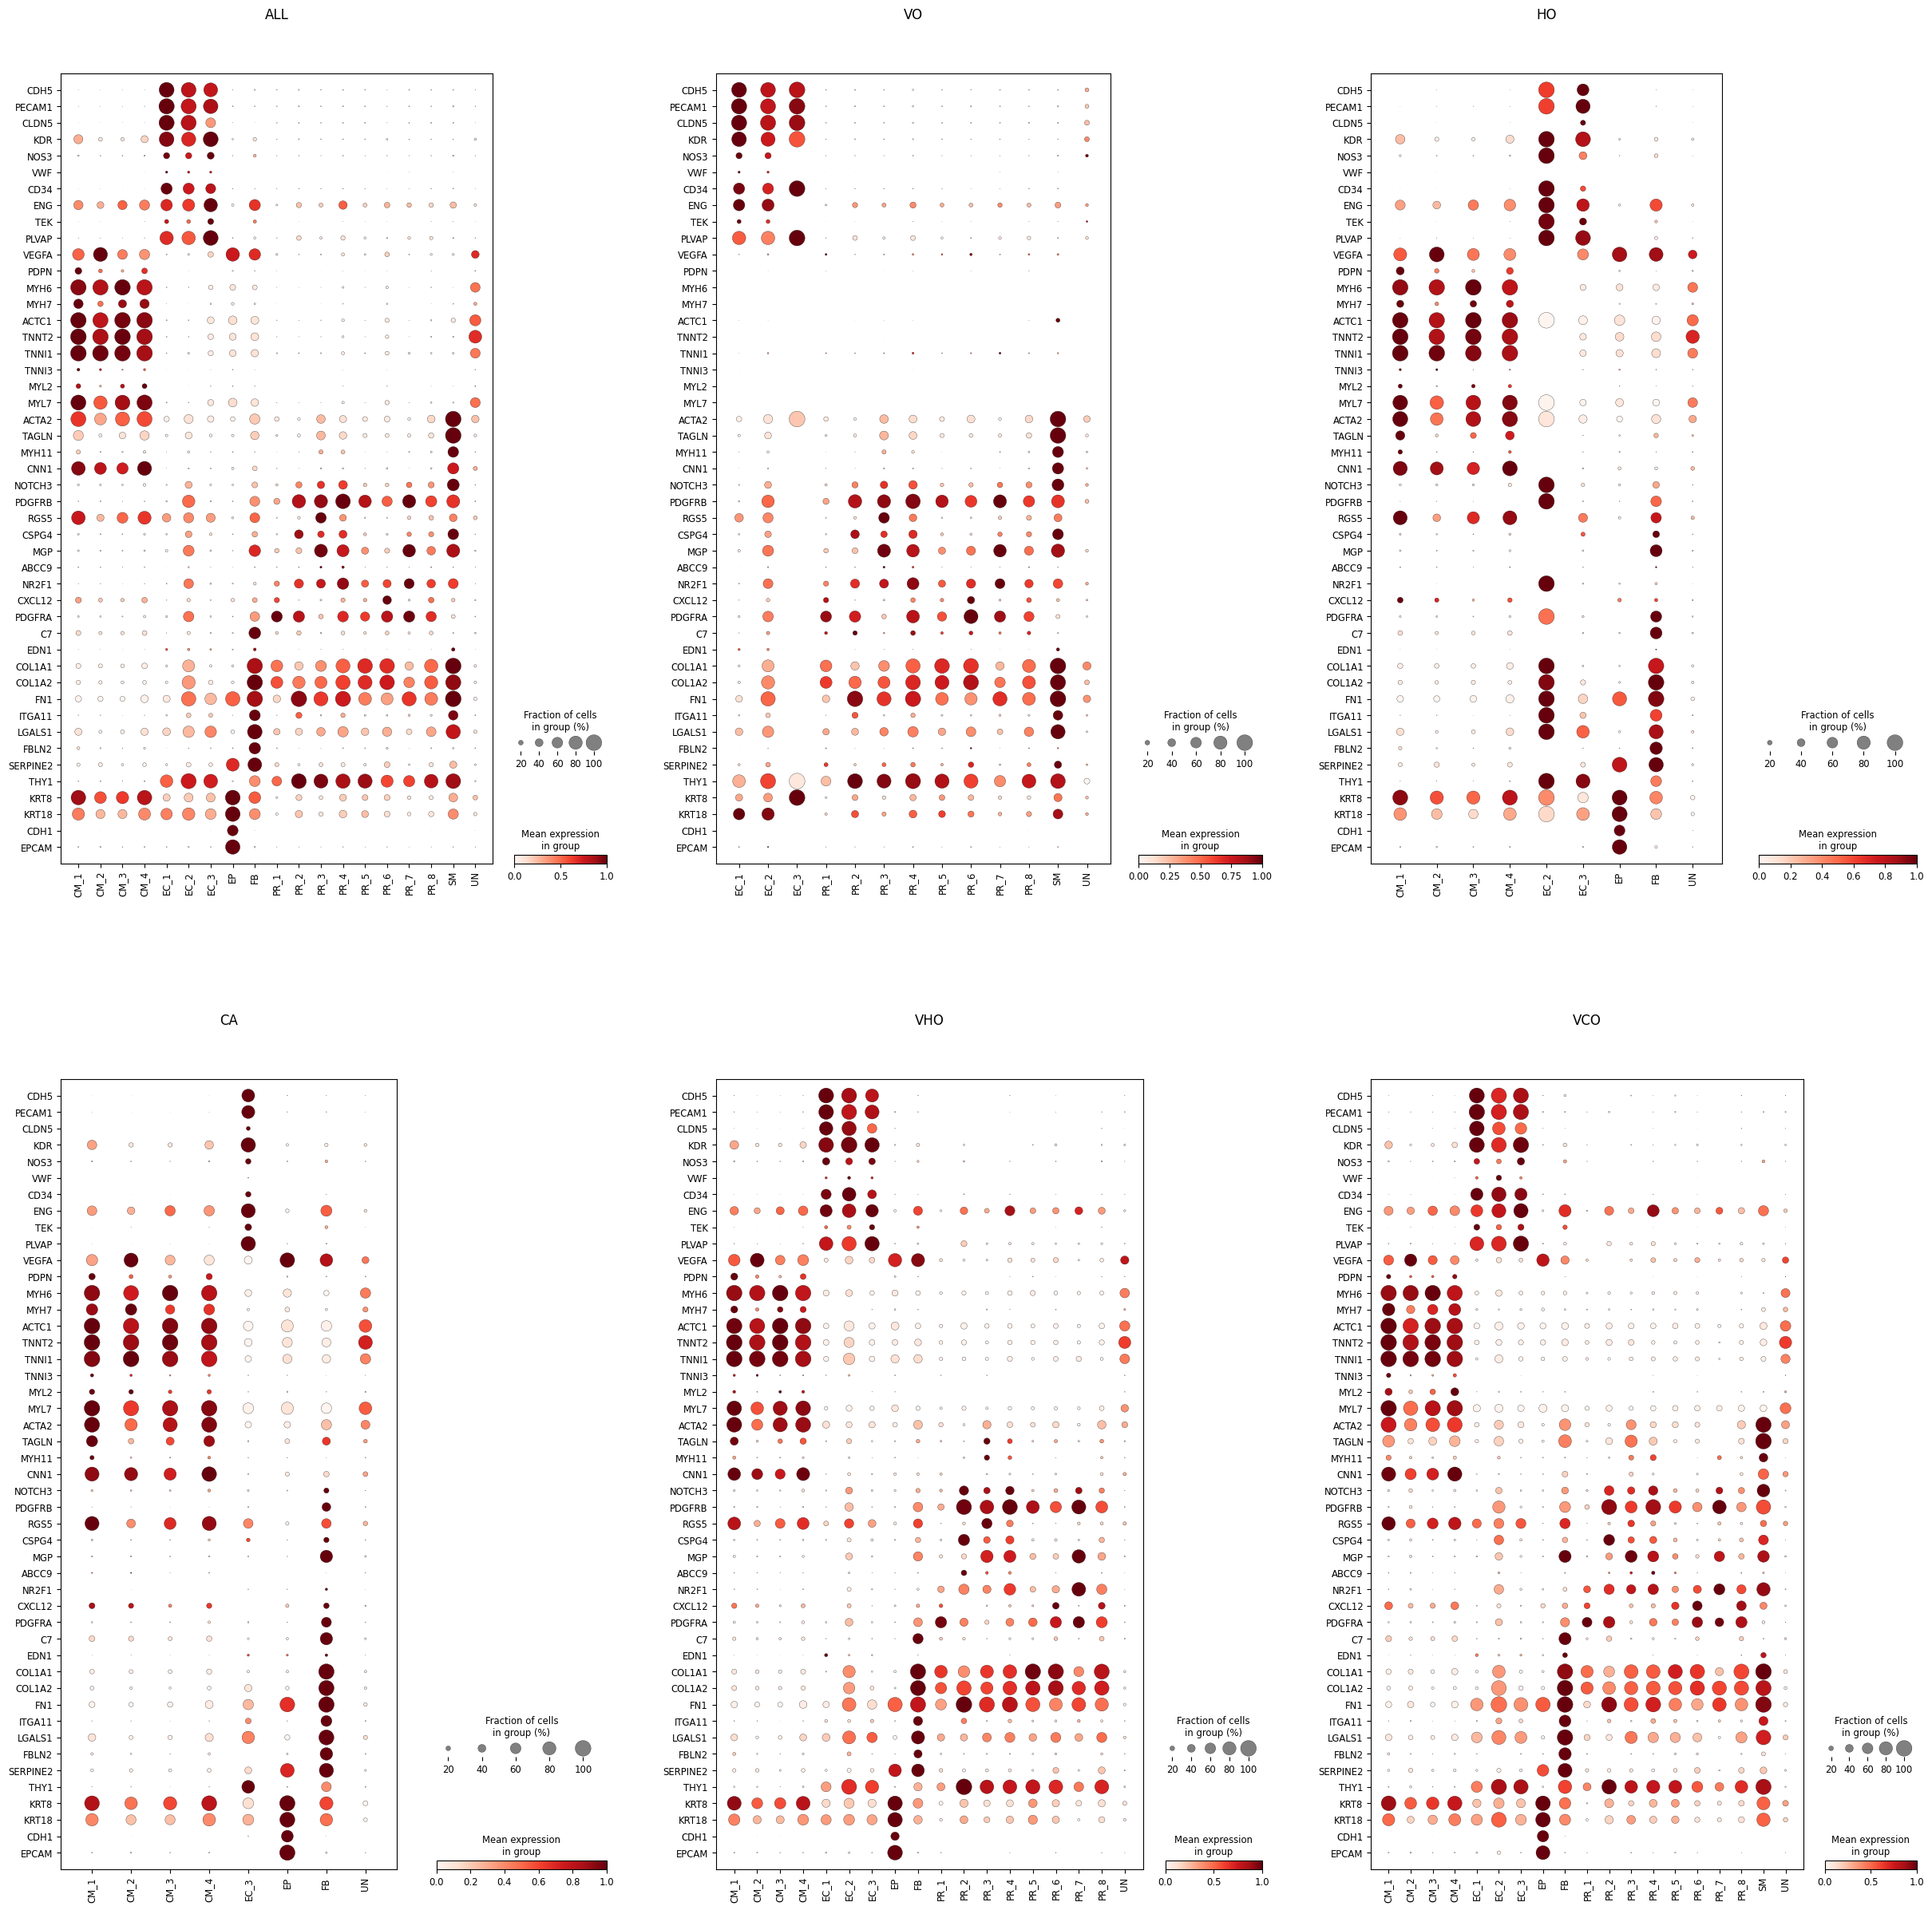

In [87]:
# marker_dict = ['CDH5', 'PECAM1', 'NOS3', 'VWF', 'CD34', 'ENG', 'FLT1', 'TEK', 'PDPN', 'MYH6', 
#                'MYH7', 'ACTC1', 'TNNT2', 'TNNI3', 'TNNI1', 'MYL2', 'MYL7', 'ACTA2', 'TAGLN', 'MYH11', 
#                'CNN1', 'DES', 'SMTN', 'VIM', 'CALD1', 'ELN', 'MYLK', 'S100A4', 'PDGFRA', 'THY1', 
#                'COL1A1', 'PDGFRB', 'CSPG4', 'RGS5', 'MCAM', 'NES', 'ITGB3', 'TGFBR1', 'TGFBR2', 'WT1', 
#                'TBX18', 'KRT8', 'KRT18', 'CDH1', 'EPCAM', 'SHH', 'RARA']

marker_dict = [
    "CDH5", "PECAM1", "CLDN5", "KDR", "NOS3", "VWF", "CD34", "ENG", "TEK", "PLVAP",
    "VEGFA", "PDPN", "MYH6", "MYH7", "ACTC1", "TNNT2", "TNNI1", "TNNI3", "MYL2", "MYL7",
    "ACTA2", "TAGLN", "MYH11", "CNN1", "NOTCH3", "PDGFRB", "RGS5", "CSPG4", "MGP", "ABCC9",
    "NR2F1", "CXCL12", "PDGFRA", "C7", "EDN1", "COL1A1", "COL1A2", "FN1", "ITGA11", "LGALS1",
    "FBLN2", "SERPINE2", "THY1", "KRT8", "KRT18", "CDH1", "EPCAM"
]

fig, axs = plt.subplots(2, 3, figsize=(30,30), layout="constrained")
axs = axs.flatten()

for i, sample_name in enumerate(samples):
    d1 = f'{WORK_DIR}/adata/sample_recollect/{sample_name}.h5ad'
    adata = sc.read_h5ad(d1)
    sc.pl.dotplot(adata, marker_dict, groupby="cell_type_subcluster", standard_scale="var", ax=axs[i], title=sample_name, show=False, swap_axes=True)
    
plt.savefig(f'{WORK_DIR}/dotplots/secondary_label.complete.png')
plt.savefig(f'{WORK_DIR}/dotplots/secondary_label.complete.svg')
plt.show()

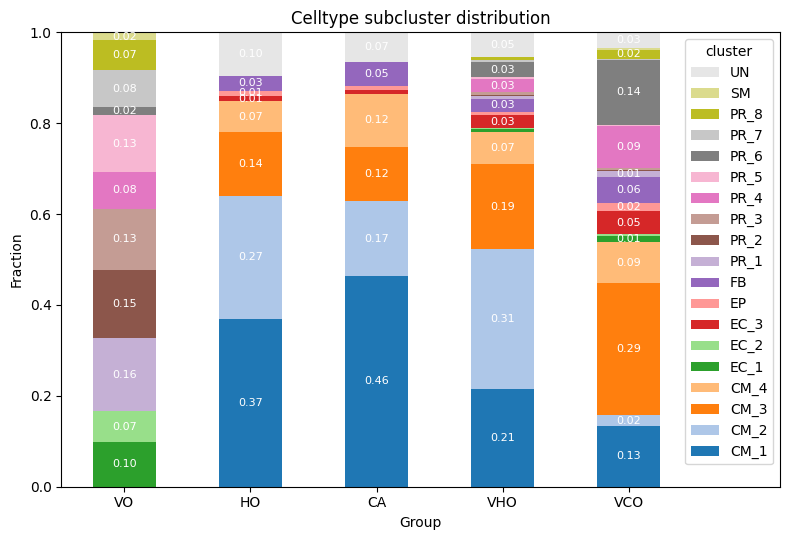

In [88]:
from matplotlib.colors import ListedColormap

colorlist1 = []
for cts in cell_type_subcluster:
    colorlist1.append(colordict1[cts])

adata = sc.read_h5ad(f"{WORK_DIR}/adata/sample_recollect/ALL.h5ad")

res = []
res_col = []

for j, sample in enumerate(samples):
    if sample == "ALL":
        continue
    adata_sample = adata[adata.obs['batch'] == sample]
    res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
    res_col.append(sample)
        
for r in res:
    r[r < MIN_CELL_COUNT] = 0
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

fig, ax = plt.subplots(1, 1, figsize=(8, 5.5))
df.plot(kind='bar', stacked=True, colormap=ListedColormap(colorlist1), ax=ax)
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 5.2))
plt.xticks(rotation=0)
plt.title("Celltype subcluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distributions/secondary_label_wCA.complete.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distributions/secondary_label_wCA.complete.svg', bbox_inches="tight")
plt.show()

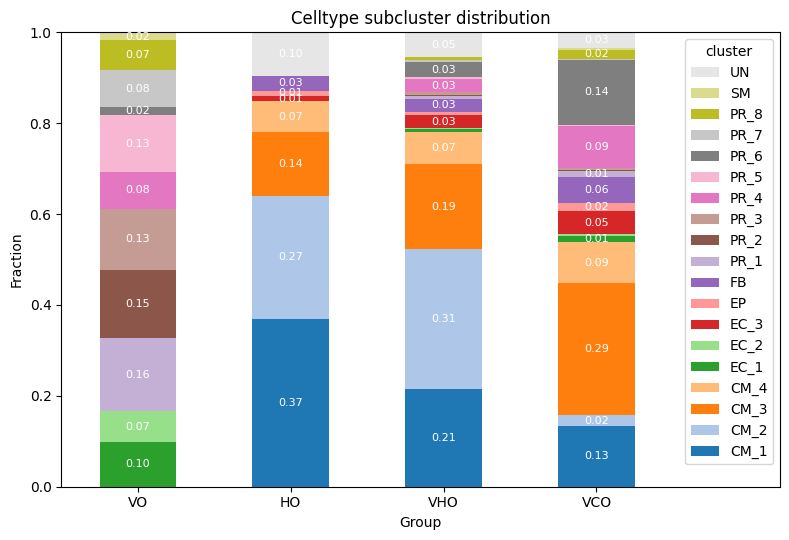

In [90]:
from matplotlib.colors import ListedColormap

colorlist1 = []
for cts in cell_type_subcluster:
    colorlist1.append(colordict1[cts])

adata = sc.read_h5ad(f"{WORK_DIR}/adata/sample_recollect/ALL.h5ad")

res = []
res_col = []

for j, sample in enumerate(samples):
    if sample == "ALL" or sample == "CA":
        continue
    adata_sample = adata[adata.obs['batch'] == sample]
    res.append(adata_sample.obs['cell_type_subcluster'].value_counts())
    res_col.append(sample)
        
for r in res:
    r[r < MIN_CELL_COUNT] = 0
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

fig, ax = plt.subplots(1, 1, figsize=(8, 5.5))
df.plot(kind='bar', stacked=True, colormap=ListedColormap(colorlist1), ax=ax)
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 4.2))
plt.xticks(rotation=0)
plt.title("Celltype subcluster distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distributions/secondary_label_woCA.complete.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distributions/secondary_label_woCA.complete.svg', bbox_inches="tight")
plt.show()

In [97]:
df.T

,VO,HO,CA,VHO,VCO,Atria_mean,Vent_mean
CM,0.000000,0.847743,0.864209,0.781124,0.537505,0.079003,0.129134
EC,0.165623,0.012564,0.008773,0.036260,0.068301,0.032021,0.020472
EP,0.000000,0.011407,0.009917,0.008253,0.018173,0.000000,0.000000
FB,0.000000,0.032237,0.052003,0.027744,0.056714,0.063780,0.039633
PR,0.816737,0.000000,0.000000,0.092362,0.280522,0.033858,0.049869
SM,0.016606,0.000000,0.000000,0.000000,0.004513,0.011024,0.005774
UN,0.001034,0.096049,0.065099,0.054258,0.034272,0.737533,0.737533
OTH,0.000000,0.000000,0.000000,0.000000,0.000000,0.042782,0.017585


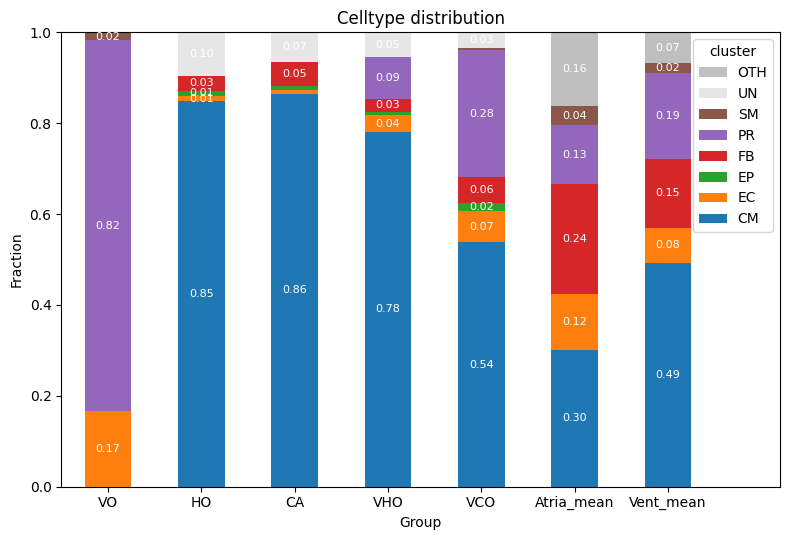

In [100]:
from matplotlib.colors import ListedColormap

colorlist2 = []
for cts in cpdb_group:
    colorlist2.append(colordict2[cts])
colorlist2.append((0.75, 0.75, 0.75))

adata = sc.read_h5ad(f"{WORK_DIR}/adata/sample_recollect/ALL.h5ad")

res = []
res_col = []

for j, sample in enumerate(samples):
    if sample == "ALL":
        continue
    adata_sample = adata[adata.obs['batch'] == sample]
    res.append(adata_sample.obs['cpdb_group'].value_counts())
    res_col.append(sample)
        
for r in res:
    r[r < MIN_CELL_COUNT] = 0
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df.loc["OTH"] = 0

df["Atria_mean"] = df["VCO"].copy()
df.loc["CM", "Atria_mean"] = 30.1
df.loc["EC", "Atria_mean"] = 12.2
df.loc["EP", "Atria_mean"] = 0
df.loc["FB", "Atria_mean"] = 24.3
df.loc["PR", "Atria_mean"] = 12.9
df.loc["SM", "Atria_mean"] = 4.2
df.loc["UN", "Atria_mean"] = 0
df.loc["OTH", "Atria_mean"] = 16.3

df["Vent_mean"] = df["Atria_mean"].copy()
df.loc["CM", "Vent_mean"] = 49.2
df.loc["EC", "Vent_mean"] = 7.8
df.loc["EP", "Vent_mean"] = 0
df.loc["FB", "Vent_mean"] = 15.1
df.loc["PR", "Vent_mean"] = 19
df.loc["SM", "Vent_mean"] = 2.2
df.loc["UN", "Vent_mean"] = 0
df.loc["OTH", "Vent_mean"] = 6.7

df = np.divide(df, df.sum())
df = df.T

fig, ax = plt.subplots(1, 1, figsize=(8, 5.5))
df.plot(kind='bar', stacked=True, colormap=ListedColormap(colorlist2), ax=ax)
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 7.2))
plt.xticks(rotation=0)
plt.title("Celltype distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distributions/cpdb_group_wCA.complete_extra.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distributions/cpdb_group_wCA.complete_extra.svg', bbox_inches="tight")
plt.show()

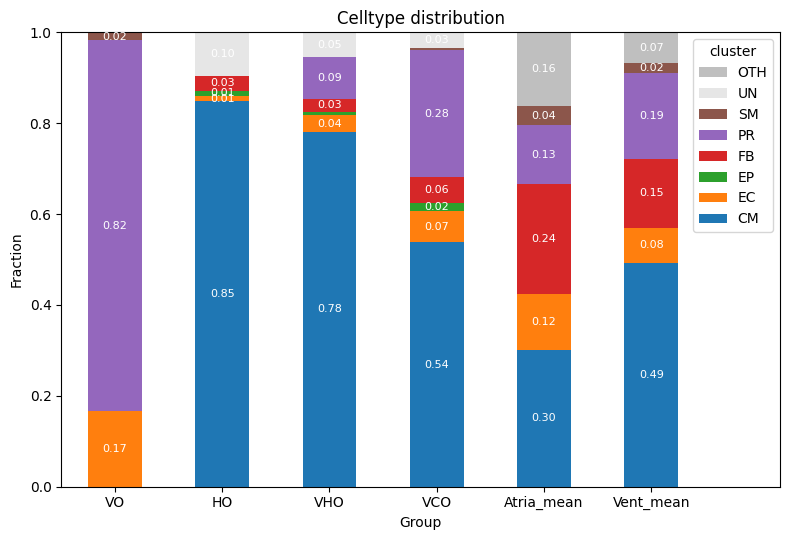

In [101]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/sample_recollect/ALL.h5ad")

res = []
res_col = []

for j, sample in enumerate(samples):
    if sample == "ALL" or sample == "CA":
        continue
    adata_sample = adata[adata.obs['batch'] == sample]
    res.append(adata_sample.obs['cpdb_group'].value_counts())
    res_col.append(sample)
        
for r in res:
    r[r < MIN_CELL_COUNT] = 0
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df.loc["OTH"] = 0

df["Atria_mean"] = df["VCO"].copy()
df.loc["CM", "Atria_mean"] = 30.1
df.loc["EC", "Atria_mean"] = 12.2
df.loc["EP", "Atria_mean"] = 0
df.loc["FB", "Atria_mean"] = 24.3
df.loc["PR", "Atria_mean"] = 12.9
df.loc["SM", "Atria_mean"] = 4.2
df.loc["UN", "Atria_mean"] = 0
df.loc["OTH", "Atria_mean"] = 16.3

df["Vent_mean"] = df["Atria_mean"].copy()
df.loc["CM", "Vent_mean"] = 49.2
df.loc["EC", "Vent_mean"] = 7.8
df.loc["EP", "Vent_mean"] = 0
df.loc["FB", "Vent_mean"] = 15.1
df.loc["PR", "Vent_mean"] = 19
df.loc["SM", "Vent_mean"] = 2.2
df.loc["UN", "Vent_mean"] = 0
df.loc["OTH", "Vent_mean"] = 6.7

df = np.divide(df, df.sum())
df = df.T

fig, ax = plt.subplots(1, 1, figsize=(8, 5.5))
df.plot(kind='bar', stacked=True, colormap=ListedColormap(colorlist2), ax=ax)
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 6.2))
plt.xticks(rotation=0)
plt.title("Celltype distribution")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='cluster')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/distributions/cpdb_group_woCA.complete_extra.png', bbox_inches="tight")
plt.savefig(f'{WORK_DIR}/distributions/cpdb_group_woCA.complete_extra.svg', bbox_inches="tight")
plt.show()

# 3. DE within celltype between different subclusters

In [10]:
%%bash
# rm -r /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/volcano/*
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/volcano/CM
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/volcano/EC
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/volcano/PR
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/volcano/inter_protocol

In [6]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/sample_recollect/ALL.h5ad")

In [7]:
def volcano_plot2(adata1, 
                  label1, 
                  label2, 
                  title, 
                  label_type='cell_type_subcluster', 
                  keygenes=None, 
                  save=None, 
                  save_tsv=None,
                  fc_thres=1, 
                  pvalue_thres=5):
    
    PSEUDOCOUNT=0.0001
    data1 = adata1.X[adata1.obs[label_type] == label1, :].todense().copy() + PSEUDOCOUNT
    data2 = adata1.X[adata1.obs[label_type] == label2, :].todense().copy() + PSEUDOCOUNT

    foldchanges = np.log2(
        np.divide(
            np.mean(data2,axis=0),
            np.mean(data1,axis=0)
        )
    )
    foldchanges = np.squeeze(np.asarray(foldchanges))

    means = np.mean(np.concatenate((data1, data2), axis=0), axis=0)
    s = np.squeeze(np.asarray(means)) ** 0.5
    s = s / s.mean() * 5

    ttest_results = scipy.stats.ttest_ind(
        data1,
        data2,
        axis=0,
        equal_var=False
    )
    pvalues = ttest_results[1]
    pvalues[pvalues == 0] = np.min(pvalues[pvalues > 0])
    transformed_pvalues = -1*np.log10(np.array(pvalues))

    idx_signi = [i for i in range(len(transformed_pvalues)) if transformed_pvalues[i] >= pvalue_thres]
    idx_inc = [i for i in idx_signi if foldchanges[i] > fc_thres]
    idx_dec = [i for i in idx_signi if foldchanges[i] < -1 * fc_thres]

    plt.scatter(foldchanges, 
                transformed_pvalues, 
                label='not significant',
                color='grey',
                alpha=0.5,
                s=s)
    plt.scatter(foldchanges[idx_inc], 
                transformed_pvalues[idx_inc], 
                label='up-regulated',
                color='red',
                alpha=0.5,
                s=s[idx_inc])
    plt.scatter(foldchanges[idx_dec], 
                transformed_pvalues[idx_dec], 
                label='down-regulated',
                color='blue',
                alpha=0.5,
                s=s[idx_dec])
    
    if keygenes is not None:
        for keygene in keygenes:
            gene_idx = adata1.var_names.tolist().index(keygene)
            plt.text(foldchanges[gene_idx], transformed_pvalues[gene_idx], keygene, ha='center', va='center')
            

    plt.xlabel('Log2FC')
    plt.ylabel('-log10 p-value')
    plt.title(title)
    plt.legend()
    if save is not None:
        plt.savefig(save)
        plt.close()
    else:
        plt.show()
    
    if save_tsv is not None:
        de_dict = {}
        de_dict['gene'] = adata1.var_names.to_list()
        de_dict['expression_1'] = np.squeeze(np.asarray(np.mean(data1, axis=0))) - PSEUDOCOUNT
        de_dict['expression_2'] = np.squeeze(np.asarray(np.mean(data2, axis=0))) - PSEUDOCOUNT
        de_dict['log2FC'] = foldchanges
        de_dict['-log10 p-val'] = transformed_pvalues
        de_dict['significant'] = [0 if (transformed_pvalues[i] < pvalue_thres or abs(foldchanges[i]) < fc_thres) else 1 for i in range(len(transformed_pvalues))]
        df = pd.DataFrame(de_dict)
        df.to_csv(save_tsv, sep='\t')
        df[df['significant'] == 1].to_csv(f"{(save_tsv).strip('.tsv')}.deg.tsv", sep='\t')

In [105]:
ct = "CM"

all_subclusters = list(adata[adata.obs['cell_type'] == ct].obs['cell_type_subcluster'].unique())
all_subclusters.sort()

for i in range(0, len(all_subclusters)):
    for j in range(i+1, len(all_subclusters)):
        subc1 = all_subclusters[i]
        subc2 = all_subclusters[j]
        volcano_plot2(adata[adata.obs['cell_type'] == ct], 
                      subc1, 
                      subc2, 
                      f"{ct}.{subc1}.{subc2}.png", 
                      keygenes=None, 
                      save=f"{WORK_DIR}/volcano/{ct}/{ct}.{subc1}.{subc2}.png", 
                      save_tsv=f"{WORK_DIR}/volcano/{ct}/{ct}.{subc1}.{subc2}.tsv")

/tmp/ipykernel_723448/679775994.py:28: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_723448/679775994.py:28: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_723448/679775994.py:28: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_723448/679775994.py:28: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_i

In [106]:
all_batches = ['VO', 'HO', 'VHO', 'CA', 'VCO']

for i in range(0, len(all_batches)):
    for j in range(i+1, len(all_batches)):
        batch1 = all_batches[i]
        batch2 = all_batches[j]
        volcano_plot2(
            adata[adata.obs["cell_type"] == "EC"], 
            batch1, 
            batch2, 
            f"EC: {batch1} vs {batch2}", 
            label_type="batch", 
            keygenes=None, 
            save=f"{WORK_DIR}/volcano/EC/EC.{batch1}.{batch2}.png", 
            save_tsv=f"{WORK_DIR}/volcano/EC/EC.{batch1}.{batch2}.tsv"
        )

/tmp/ipykernel_723448/679775994.py:28: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_723448/679775994.py:28: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_723448/679775994.py:28: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_723448/679775994.py:28: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_i

In [107]:
keygenes = ['ACVRL1', 'KDR', 'TEK', 'ANGPT2', 'NOTCH1', 
            'NOTCH2', 'NOTCH3', 'NOTCH4', 'NRG1', 'TGFB1', 
            'ERBB4', 'EDN1', 'C7', 'FN1', 'PLXDC2', 'PTN', 
            'RGS5', 'COL4A1', 'COL1A1', 'CXCL12', 'VEGFA']

ct = "EC"

all_subclusters = list(adata[adata.obs['cell_type'] == ct].obs['cell_type_subcluster'].unique())
all_subclusters.sort()

for i in range(0, len(all_subclusters)):
    for j in range(i+1, len(all_subclusters)):
        subc1 = all_subclusters[i]
        subc2 = all_subclusters[j]
        volcano_plot2(adata[adata.obs['cell_type'] == ct], 
                      subc1, 
                      subc2, 
                      f"{ct}.{subc1}.{subc2}.png", 
                      keygenes=keygenes, 
                      save=f"{WORK_DIR}/volcano/{ct}/{ct}.{subc1}.{subc2}.png", 
                      save_tsv=f"{WORK_DIR}/volcano/{ct}/{ct}.{subc1}.{subc2}.tsv")

In [108]:
ct = "PR"

all_subclusters = list(adata[adata.obs['cell_type'] == 'MU'].obs['cell_type_subcluster'].unique())
all_subclusters.sort()
all_subclusters.remove("FB")
all_subclusters.remove("SM")

for i in range(0, len(all_subclusters)):
    for j in range(i+1, len(all_subclusters)):
        subc1 = all_subclusters[i]
        subc2 = all_subclusters[j]
        volcano_plot2(adata[adata.obs['cell_type'] == 'MU'], 
                      subc1, 
                      subc2, 
                      f"{ct}.{subc1}.{subc2}.png", 
                      keygenes=None, 
                      save=f"{WORK_DIR}/volcano/{ct}/{ct}.{subc1}.{subc2}.png", 
                      save_tsv=f"{WORK_DIR}/volcano/{ct}/{ct}.{subc1}.{subc2}.tsv")

/tmp/ipykernel_723448/679775994.py:28: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_723448/679775994.py:28: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_723448/679775994.py:28: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_ind(
/tmp/ipykernel_723448/679775994.py:28: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  ttest_results = scipy.stats.ttest_i

In [9]:
adata.obs["cpdb_group"]

AAACCCAAGAAGGGAT-1-0    CM
AAACCCAAGTCAGGGT-1-0    CM
AAACCCACATCCAACA-1-0    CM
AAACCCAGTAGATGTA-1-0    CM
AAACCCAGTAGTACGG-1-0    CM
                        ..
TTTACCACAGCGTACC-1-4    UN
TTTACCAGTCTGCATA-1-4    UN
TTTACCATCTACCAGA-1-4    UN
TTTCATGGTCATAGTC-1-4    UN
TTTGGAGAGAGCCGAT-1-4    UN
Name: cpdb_group, Length: 51885, dtype: category
Categories (7, object): ['CM', 'EC', 'EP', 'FB', 'PR', 'SM', 'UN']

In [109]:
ct = ['']
samples = ['VO','HO','CA','VHO','VCO']

volcano_plot2(adata1=adata[adata.obs["cpdb_group"] == "PR"], 
              label1="VO", 
              label2 = "VCO", 
              title = "Pericyte VO vs VCO", 
              label_type='batch', 
              keygenes=None, 
              save=f"{WORK_DIR}/volcano/PR/PR.VO.VCO.png", 
              save_tsv=f"{WORK_DIR}/volcano/PR/PR.VO.VCO.tsv",
              fc_thres=2, 
              pvalue_thres=5)

# 4. Velocity

In [34]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/velocity
# cp /home/herbert/PyProjects/cocultured_organ/workspace/CCO06/velocity/scVelo_job.* /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/velocity/

In [15]:
%%bash
qsub /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/velocity/scVelo_job.sh

requested Hard Resources
  memory (s_vmem): 128G = The job requires 128GB of memory per slot.
  slots (def_slot): 1 = The job requires 100% of CPU.
  total memory: 128G = The job requires 128GB of memory.
Your job 116516583 ("scVelo_job.sh") has been submitted


# 5. Label transferring with HVCA

In [110]:
%%bash
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/label_transfer

In [111]:
adata_HVCA = sc.read_h5ad(f"{WORK_DIR}/adata/HVCA/global_object_vasc_atlas_cxg.h5ad")
adata_HVCA_EN = adata_HVCA[adata_HVCA.obs["cell_type"] == "Endothelial cells"]

In [112]:
sc.pp.filter_cells(adata_HVCA_EN, min_genes=200)
sc.pp.filter_genes(adata_HVCA_EN, min_cells=3)
sc.pp.normalize_total(adata_HVCA_EN, target_sum=1e4)
sc.pp.log1p(adata_HVCA_EN)

In [113]:
adata = sc.read_h5ad(f"{WORK_DIR}/adata/sample_recollect/ALL.h5ad")

In [114]:
adata_source = sc.pp.subsample(adata_HVCA_EN, n_obs=10000, random_state=42, copy=True)
adata_target = adata[adata.obs["cell_type"] == "EC"]

adata_target.obs["organ_uni"] = "Unknown"

In [115]:
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import TruncatedSVD

# Step 1: Align genes
common_genes = adata_source.var_names.intersection(adata_target.var_names)
adata_source = adata_source[:, common_genes].copy()
adata_target = adata_target[:, common_genes].copy()

# Step 2: Concatenate for shared processing
adata_combined = ad.concat([adata_source, adata_target], label="dataset", keys=["source", "target"])

# Step 3: Normalize & scale
# sc.pp.normalize_total(adata_combined, target_sum=1e4)
# sc.pp.log1p(adata_combined)
# sc.pp.scale(adata_combined)

# Step 4: Dimensionality reduction (PCA)
n_pcs = 50  # can adjust based on dataset size
svd = TruncatedSVD(n_components=n_pcs)
X_pca = svd.fit_transform(adata_combined.X)

# Step 5: Split PCA embeddings
source_mask = adata_combined.obs["dataset"] == "source"
target_mask = ~source_mask

X_source = X_pca[source_mask]
X_target = X_pca[target_mask]

y_source = adata_combined.obs.loc[source_mask, "organ_uni"]

# Step 6: Train classifier on source labels
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_source, y_source)

# Step 7: Predict labels for target
predicted_labels = knn.predict(X_target)

# Step 8: Add predictions back to target AnnData
adata_target.obs["organ_uni_pred"] = predicted_labels

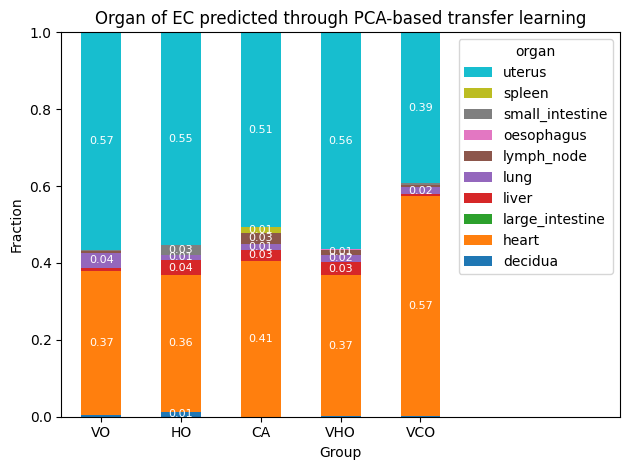

In [116]:
samples = ['ALL','VO','HO','CA','VHO','VCO']

res = []
res_col = []

for j, sample in enumerate(samples):    
    if sample == 'ALL':
        continue
    else:
        adata_sample = adata_target[adata_target.obs['batch'] == sample]
        res.append(adata_sample.obs['organ_uni_pred'].value_counts())
        res_col.append(sample)
        
# for r in res:
#     r[r < MIN_CELL_COUNT] = 0
        
all_categories = sorted(set().union(*[s.index for s in res]))
aligned_series = [s.reindex(all_categories, fill_value=0) for s in res]
df = pd.DataFrame(aligned_series, index=res_col)
df = df.T
df = np.divide(df, df.sum())
df = df.T

ax = df.plot(kind='bar', stacked=True)
plt.xlabel('Group')
plt.ylabel('Fraction')
plt.ylim((0, 1))
plt.xlim((-0.5, 6.5))
plt.xticks(rotation=0)
plt.title("Organ of EC predicted through PCA-based transfer learning")

# Reverse legend to match stack order
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title='organ')

# Add fraction labels
for bar in ax.containers:
    for rect in bar:
        height = rect.get_height()
        if height > 0.01:  # Avoid cluttering small segments
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_y() + height / 2,
                f'{height:.2f}',
                ha='center', va='center', fontsize=8, color='white'
            )

plt.tight_layout()
plt.savefig(f"{WORK_DIR}/label_transfer/tl.pca.png")
plt.show()

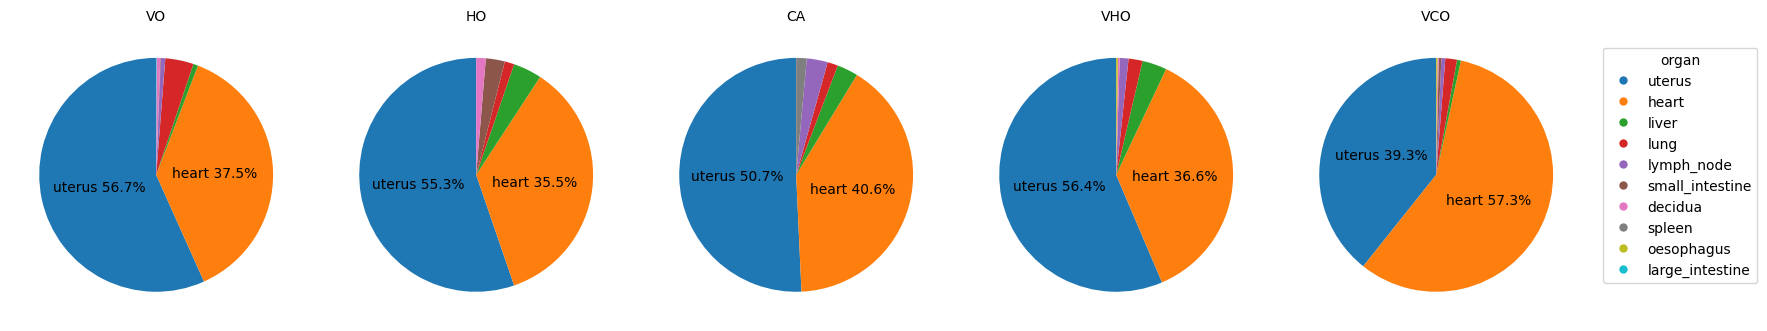

In [134]:
# --- CONFIG ---
min_pct_to_label = 10.0   # show label + leader line only if >= this %
outer_label_offset = 0.5  # how far outside labels sit
donut_width = 1         # 0 for full pie, >0 for donut
cmap_name = 'tab10'        # unified color map name

# unified color map for organs (columns)
df = df[df.mean(axis=0).sort_values(ascending=False).index]
organs = list(df.columns)
cmap = plt.get_cmap(cmap_name)
colors = {org: cmap(i % cmap.N) for i, org in enumerate(organs)}

# layout
n = len(df)
fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3.2), constrained_layout=True)
if n == 1:
    axes = [axes]

for ax, (group, row) in zip(axes, df.iterrows()):
    vals = row.values.astype(float)
    total = vals.sum()
    colseq = [colors[o] for o in organs]

    # draw pie/donut
    wedges, _ = ax.pie(
        vals,
        startangle=90,
        labels=None,                   # no on-slice labels
        colors=colseq,
        wedgeprops=dict(width=donut_width) if donut_width > 0 else None
    )

    # label only larger slices, outside with leader lines
    if total > 0:
        for w, v, label in zip(wedges, vals, organs):
            pct = 100.0 * v / total
            if pct >= min_pct_to_label:
                ang = 0.5 * (w.theta2 + w.theta1)
                ang_rad = np.deg2rad(ang)
                x, y = np.cos(ang_rad), np.sin(ang_rad)
                ax.annotate(
                    f'{label} {pct:.1f}%',
                    xy=(x, y),
                    xytext=(outer_label_offset * x, outer_label_offset * y),
                    ha='center', va='center',
                    fontsize=10,
                    arrowprops=dict(arrowstyle='-', lw=0)
                )

    ax.set_title(str(group), fontsize=10)
    ax.set_aspect('equal')

# single unified legend (outside)
legend_handles = [
    plt.Line2D([0], [0], marker='o', linestyle='',
               markerfacecolor=colors[o], markeredgecolor='none', label=o)
    for o in organs
]
fig.legend(handles=legend_handles, title='organ', loc='center left', bbox_to_anchor=(1.0, 0.5))
# fig.suptitle("Organ of EC predicted through PCA-based transfer learning", y=1.03)

# save/show
plt.savefig(f"{WORK_DIR}/label_transfer/tl.pca.pie.png", bbox_inches='tight')
plt.savefig(f"{WORK_DIR}/label_transfer/tl.pca.pie.svg", bbox_inches='tight')
plt.show()

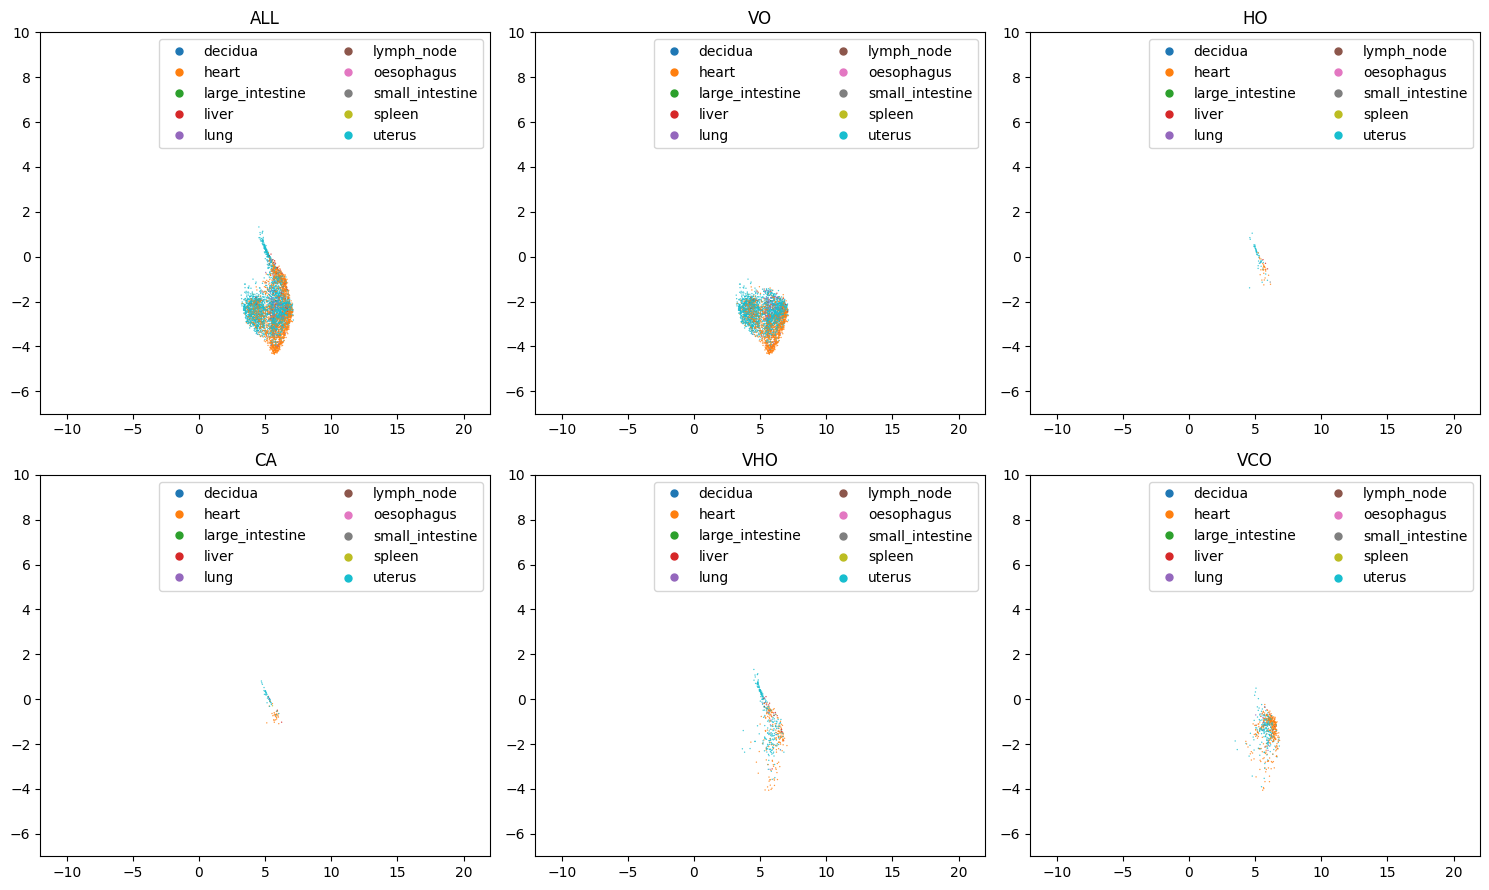

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap

fig, axs = plt.subplots(2, 3, figsize=(15, 9))
axs = axs.flatten()

rng = np.random.default_rng(42)  # set or drop seed for reproducibility

# Use a stable color per organ label
all_orgs = list(np.unique(adata_target.obs['organ_uni_pred']))
prop_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = {org: prop_cycle[i % len(prop_cycle)] for i, org in enumerate(all_orgs)}
cmap = ListedColormap([colors[o] for o in all_orgs])
org_to_id = {o: i for i, o in enumerate(all_orgs)}

for j, sample in enumerate(samples):
    ax = axs[j]
    adata_sample = adata_target if sample == 'ALL' else adata_target[adata_target.obs['batch'] == sample]

    # Build stacked arrays
    orgs_sub = adata_sample.obs['organ_uni_pred'].to_numpy()
    xy = adata_sample.obsm['X_umap']  # shape (N, 2)
    c = np.array([org_to_id[o] for o in orgs_sub], dtype=int)

    # Global shuffle across ALL points so labels interleave
    perm = rng.permutation(xy.shape[0])
    xy = xy[perm]
    c  = c[perm]

    sc = ax.scatter(xy[:, 0], xy[:, 1],
                    c=c, cmap=cmap, vmin=-0.5, vmax=len(all_orgs)-0.5,
                    s=1, alpha=0.8, linewidths=0, rasterized=True)

    ax.set_xlim([-12, 22])
    ax.set_ylim([-7, 10])
    ax.set_title(f"{sample}")

    # Custom legend with fixed colors per label
    handles = [Line2D([0], [0], marker='o', linestyle='', markersize=1,
                      color=colors[o], label=o) for o in all_orgs]
    ax.legend(handles=handles, loc='upper right', markerscale=5, ncol=2)

plt.tight_layout()
plt.savefig(f'{WORK_DIR}/label_transfer/tl.pca.umap.png', dpi=300)
plt.show()

In [16]:
def volcano_plot(adata1, adata2, title, keygenes=None, save=None, save_tsv=None):
    
    fc_thres = 2
    pvalue_thres = 5
    
    if np.any(adata1.var_names != adata2.var_names):
        raise ValueError('adata var names not unified')
    
    PSEUDOCOUNT=0.001
    data1 = adata1.X.todense().copy() + PSEUDOCOUNT
    data2 = adata2.X.todense().copy() + PSEUDOCOUNT

    foldchanges = np.log2(
        np.divide(
            np.mean(data2,axis=0),
            np.mean(data1,axis=0)
        )
    )
    foldchanges = np.squeeze(np.asarray(foldchanges))

    means = np.mean(np.concatenate((data1, data2), axis=0), axis=0)
    s = np.squeeze(np.asarray(means)) ** 0.5
    s = s / s.mean() * 5

    ttest_results = scipy.stats.ttest_ind(
        data1,
        data2,
        axis=0,
        equal_var=False
    )
    pvalues = ttest_results[1]
    pvalues[pvalues == 0] = np.min(pvalues[pvalues > 0])
    transformed_pvalues = -1*np.log10(np.array(pvalues))

    idx_signi = [i for i in range(len(transformed_pvalues)) if transformed_pvalues[i] >= pvalue_thres]
    idx_inc = [i for i in idx_signi if foldchanges[i] > fc_thres]
    idx_dec = [i for i in idx_signi if foldchanges[i] < -1 * fc_thres]

    plt.scatter(foldchanges, 
                transformed_pvalues, 
                label='not significant',
                color='grey',
                alpha=0.5,
                s=s)
    plt.scatter(foldchanges[idx_inc], 
                transformed_pvalues[idx_inc], 
                label='up-regulated',
                color='red',
                alpha=0.5,
                s=s[idx_inc])
    plt.scatter(foldchanges[idx_dec], 
                transformed_pvalues[idx_dec], 
                label='down-regulated',
                color='blue',
                alpha=0.5,
                s=s[idx_dec])
    
    if keygenes is not None:
        for keygene in keygenes:
            gene_idx = adata1.var_names.tolist().index(keygene)
            plt.text(foldchanges[gene_idx], transformed_pvalues[gene_idx], keygene)
            

    plt.xlabel('Log2FC')
    plt.ylabel('-log10 p-value')
    plt.title(title)
    plt.legend()
    if save is not None:
        plt.savefig(save)
        plt.close()
    else:
        plt.show()
    
    if save_tsv is not None:
        de_dict = {}
        de_dict['gene'] = adata1.var_names.to_list()
        de_dict['expression_1'] = np.squeeze(np.asarray(np.mean(data1, axis=0))) - PSEUDOCOUNT
        de_dict['expression_2'] = np.squeeze(np.asarray(np.mean(data2, axis=0))) - PSEUDOCOUNT
        de_dict['log2FC'] = foldchanges
        de_dict['-log10 p-val'] = transformed_pvalues
        de_dict['significant'] = [0 if (transformed_pvalues[i] < pvalue_thres or abs(foldchanges[i]) < fc_thres) else 1 for i in range(len(transformed_pvalues))]
        df = pd.DataFrame(de_dict)
        df.to_csv(save_tsv, sep='\t')
        df[df['significant'] == 1].to_csv(f"{(save_tsv).strip('.tsv')}.deg.tsv", sep='\t')

In [17]:
adata_HVCA_EN_CM = adata_HVCA_EN[adata_HVCA_EN.obs['organ_uni'] == 'heart']
adata_HVCA_EN_nonCM = adata_HVCA_EN[adata_HVCA_EN.obs['organ_uni'] != 'heart']
volcano_plot(adata_HVCA_EN_CM, adata_HVCA_EN_nonCM, title=None, keygenes=None, save=f'{WORK_DIR}/label_transfer/HVCA_volcano.png', save_tsv=f'{WORK_DIR}/label_transfer/HVCA_volcano.tsv')

In [26]:
df = pd.read_csv(f"{WORK_DIR}/label_transfer/HVCA_volcano.deg.tsv", sep='\t')
df.sort_values(by='expression_1', ascending=False).head(n=10)['gene'].to_list()

['TCF15',
 'FMO2',
 'CLIC5',
 'SLC14A1',
 'LPL',
 'TNNT3',
 'CA8',
 'LGALS3BP',
 'ISOC1',
 'NDNF']

/home/herbert/anaconda3/envs/cco/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


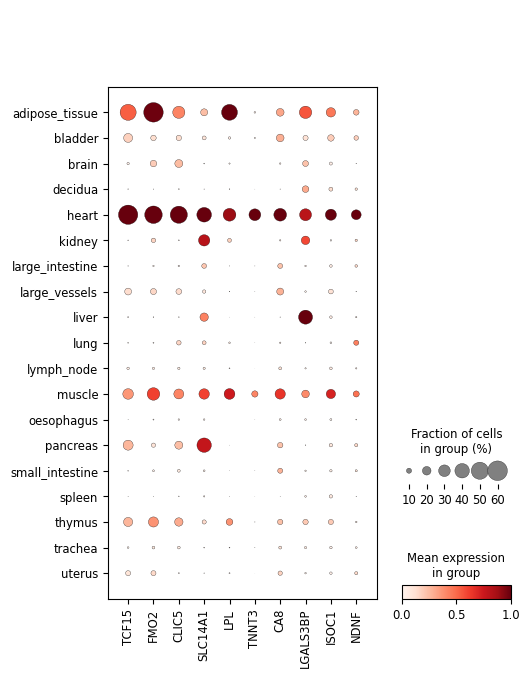

In [27]:
sc.pl.dotplot(
    adata_HVCA_EN, 
    ['TCF15','FMO2','CLIC5','SLC14A1','LPL','TNNT3','CA8','LGALS3BP','ISOC1','NDNF'], 
    groupby="organ_uni", 
    standard_scale="var")

# 6. CellPhoneDB
 - switch to cellphonedb env

In [1]:
%%bash
rm -r /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/processed
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/adata
mkdir -p /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/figs

In [11]:
import os

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import ktplotspy as kpy
import seaborn as sns
import matplotlib.pyplot as plt

from glob import glob
import glob
from tqdm import tqdm

from cellphonedb.src.core.methods import cpdb_analysis_method,cpdb_statistical_analysis_method

In [3]:
data_dir  = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/adata"
work_dir  = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb"
cpdb_path = "/home/brett/work/Cell2CellCommunication/cpdb/database/v5.0.0/cellphonedb.zip"
processed_dir = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/processed"
figs_dir = "/home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/figs"

In [4]:
# def normalize_c(value):
#     if isinstance(value, str) and value.startswith('MU_'):
#         return 'MU'
#     return value

# adata_vco = sc.read_h5ad(f"/home/herbert/PyProjects/cocultured_organ/workspace/CCO07/adata/sample_recollect/VCO.h5ad")
# sc.pp.highly_variable_genes(adata_vco, n_top_genes=4000)

for adata_path in glob(f"/home/herbert/PyProjects/cocultured_organ/workspace/CCO07/adata/sample_recollect/*.h5ad"):
    basename = adata_path.split('/')[-1]
    if basename == "ALL.h5ad":
        continue
    adata = sc.read_h5ad(adata_path)
    sc.pp.highly_variable_genes(adata, n_top_genes=4000)
    # adata.obs['cell_type_subcluster'] = adata.obs['cell_type_subcluster'].apply(normalize_c)
    # adata.var["highly_variable"] = adata_vco.var["highly_variable"]
    
    adata.write_h5ad(f"{data_dir}/{basename}")

In [5]:
pattern = os.path.join(data_dir,"*.h5ad")
for adata_path in glob(pattern):
    # if ("/HO.h5ad" not in adata_path) and ("/VCO.h5ad" not in adata_path):
    #     continue
    print(adata_path)

    label = os.path.basename(adata_path).split(".")[0]
    adata = sc.read_h5ad(adata_path)
    adata = adata[:,adata.var['highly_variable']]
    updated_adata_path = os.path.join(processed_dir,os.path.basename(adata_path.replace(".h5ad",".hvg.h5ad")))
    adata.write(updated_adata_path,compression="gzip")

    metadata_df = pd.DataFrame({
        "barcode_sample" : adata.obs_names,
        "cell_type"      : adata.obs['cpdb_group'].to_list()
    })

    metadata_df.index = np.arange(metadata_df.shape[0])
    metadata_path     = os.path.join(work_dir,f"{label}.statistical.metadata.tsv")
    metadata_df.to_csv(metadata_path,index=False,sep="\t")

    out_dir      = os.path.join(work_dir,f"{label}.statistical")
    # Threshold:0.1 Iterations:1000 Debug-seed:-1 Threads:4 Precision:3
    cpdb_results = cpdb_statistical_analysis_method.call(
        cpdb_file_path     = cpdb_path,         # mandatory: CellphoneDB database zip file.
        meta_file_path     = metadata_path,     # mandatory: tsv file defining barcodes to cell label.
        counts_file_path   = updated_adata_path,# mandatory: normalized count matrix - a path to the counts file, or an in-memory AnnData object
        counts_data        = 'gene_name',       # defines the gene annotation in counts matrix.
        score_interactions = True,              # optional: whether to score interactions or not. 
        output_path        = out_dir,           # Path to save results
        pvalue             = 0.05
    )

/home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/adata/VO.h5ad
Reading user files...
The following user files were loaded successfully:
/home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/processed/VO.hvg.h5ad
/home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/VO.statistical.metadata.tsv
[ ][CORE][24/09/25-15:36:26][INFO] [Cluster Statistical Analysis] Threshold:0.1 Iterations:1000 Debug-seed:-1 Threads:4 Precision:3
[ ][CORE][24/09/25-15:36:27][INFO] Running Real Analysis
[ ][CORE][24/09/25-15:36:27][INFO] Running Statistical Analysis


100%|███████████████████████████████████████| 1000/1000 [00:38<00:00, 25.66it/s]

[ ][CORE][24/09/25-15:37:06][INFO] Building Pvalues result


[ ][CORE][24/09/25-15:37:06][INFO] Building results
[ ][CORE][24/09/25-15:37:07][INFO] Scoring interactions: Filtering genes per cell type..


100%|█████████████████████████████████████████████| 4/4 [00:00<00:00, 42.70it/s]

...

[ ][CORE][24/09/25-15:38:24][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..



100%|████████████████████████████████████████████| 5/5 [00:00<00:00, 453.83it/s]


[ ][CORE][24/09/25-15:38:25][INFO] Scoring interactions: Calculating scores for all interactions and cell types..


100%|██████████████████████████████████████████| 25/25 [00:00<00:00, 145.31it/s]


Saved deconvoluted to /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/CA.statistical/statistical_analysis_deconvoluted_09_24_2025_153825.txt
Saved deconvoluted_percents to /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/CA.statistical/statistical_analysis_deconvoluted_percents_09_24_2025_153825.txt
Saved means to /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/CA.statistical/statistical_analysis_means_09_24_2025_153825.txt
Saved pvalues to /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/CA.statistical/statistical_analysis_pvalues_09_24_2025_153825.txt
Saved significant_means to /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/CA.statistical/statistical_analysis_significant_means_09_24_2025_153825.txt
Saved interaction_scores to /home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/CA.statistical/statistical_analysis_interaction_scores_09_24_2025_153825.txt


In [8]:
pattern = os.path.join(work_dir,"*.statistical")
date = "09_24_2025"

In [9]:
pattern = os.path.join(work_dir,"*.statistical")
date = "09_24_2025"
for cpdb_dir in glob(pattern):
    label = os.path.basename(cpdb_dir).replace(".statistical","")
    means_path         = glob(os.path.join(cpdb_dir,f"statistical_analysis_means_{date}_*.txt"))[0]
    pvals_path         = glob(os.path.join(cpdb_dir,f"statistical_analysis_pvalues_{date}_*.txt"))[0]
    deconvolution_path = glob(os.path.join(cpdb_dir,f"statistical_analysis_deconvoluted_{date}_*.txt"))[0]
    interaction_path   = glob(os.path.join(cpdb_dir,f"statistical_analysis_interaction_scores_{date}_*.txt"))[0]

    means_df         = pd.read_csv(means_path,sep="\t")
    pvals_df         = pd.read_csv(pvals_path,sep="\t")
    deconvolution_df = pd.read_csv(deconvolution_path,sep="\t")
    interaction_df   = pd.read_csv(interaction_path,sep="\t")

    adata_path = os.path.join(data_dir,f"{label}.h5ad")
    adata      = ad.read_h5ad(adata_path)
    adata.obs["cpdb_key"] = adata.obs["cpdb_group"]
    # adata.obs["cpdb_key"] = adata.obs["cell_type"]

    for cpdb_key in tqdm(adata.obs["cpdb_key"].unique(),desc=label):
        df = kpy.plot_cpdb(
            adata=adata,
            cell_type1=cpdb_key,
            cell_type2=".",
            means=means_df,
            pvals=pvals_df,
            celltype_key="cpdb_key",
            highlight_size=1,
            figsize=(24,24),
            title=f"{label} {cpdb_key}",
            default_style=False,
            return_table=True
        )
        df.index = [index.replace(">@<","-") for index in df.index]
        df["interaction_group"] = [group.replace(">@<","-").split("---")[-1] for group in df["interaction_group"]]
        df["significant"] = df["significant"].fillna("no")
        df_path = os.path.join(cpdb_dir,f"{label}__{cpdb_key}.csv")
        df.to_csv(df_path)

HO: 100%|█████████████████████████████████████████| 5/5 [00:00<00:00, 10.73it/s]


In [13]:
import os, re
import pandas as pd
from collections import Counter, defaultdict

alpha = 0.05  # significance cutoff
pair_col_pat = re.compile(r"(.+)\|(.+)")  # CPDB pvals col pattern "A|B"

def extract_pair_columns(df, keep_celltypes):
    """Return list of pvalue columns that look like 'A|B' and both A,B in keep_celltypes."""
    cols = []
    for c in df.columns:
        m = pair_col_pat.fullmatch(c)
        if m:
            A, B = m.group(1), m.group(2)
            if (A in keep_celltypes) and (B in keep_celltypes):
                cols.append((c, A, B))
    return cols

def count_sig_per_pair(pvals_df, keep_celltypes, alpha=0.05):
    """Count significant interactions per directed pair (A,B)."""
    out = defaultdict(int)
    pair_cols = extract_pair_columns(pvals_df, keep_celltypes)
    for c, A, B in pair_cols:
        # Each row is one interacting_pair; count how many are significant for this A|B column
        out[(A, B)] = int((pvals_df[c] < alpha).sum())
    return out

# ---- main: iterate runs and collect counts ----
counts_by_run = {}                       # label -> {(A,B): count}
all_pairs = set()                        # union of all (A,B) seen
work_dir = work_dir                      # assumes you already defined this
date = date                              # assumes you already defined this
pattern = os.path.join(work_dir,"*.statistical")

for cpdb_dir in glob.glob(pattern):
    label = os.path.basename(cpdb_dir).replace(".statistical","")
    means_df = pd.read_csv(glob.glob(f"{cpdb_dir}/statistical_analysis_means_{date}_*.txt")[0], sep='\t')
    pvals_df = pd.read_csv(glob.glob(f"{cpdb_dir}/statistical_analysis_pvalues_{date}_*.txt")[0], sep='\t')
    decon_df = pd.read_csv(glob.glob(f"{cpdb_dir}/statistical_analysis_deconvoluted_{date}_*.txt")[0], sep='\t')
    adata = sc.read_h5ad(f"{work_dir}/adata/{label}.h5ad")

    # use your existing cts list; if you prefer to derive from adata:
    cts = sorted(adata.obs['cpdb_group'].unique())

    pair_counts = count_sig_per_pair(pvals_df, cts, alpha=alpha)
    counts_by_run[label] = pair_counts
    all_pairs.update(pair_counts.keys())

# ---- assemble a comparison table: rows=(A,B), columns=runs ----
all_pairs = sorted(all_pairs)  # stable order
summary_df = pd.DataFrame(
    index=pd.MultiIndex.from_tuples(all_pairs, names=["celltype_A", "celltype_B"]),
    columns=sorted(counts_by_run.keys()),
    data=0
)
for label, pc in counts_by_run.items():
    for k, v in pc.items():
        summary_df.loc[k, label] = v

# Optional: add totals per run and per (A,B)
summary_df["MAX_across_runs"] = summary_df.max(axis=1)
run_totals = summary_df.drop(columns=["MAX_across_runs"]).sum(axis=0).to_frame(name="TOTAL_significant_pairs")
global_max = int(summary_df["MAX_across_runs"].max())

print("Global maximum significant links for any (A,B):", global_max)
print("\nTotals per run (sum of all (A,B) significant links):")
print(run_totals.sort_values("TOTAL_significant_pairs", ascending=False))

# ---- N_max for padding step (per directed pair) ----
# Dictionary you can pass to your padding routine:
N_max = {pair: int(max(summary_df.loc[pair, summary_df.columns != "MAX_across_runs"])) for pair in all_pairs}

# Example: inspect a few pairs
print("\nExample (first 10 pairs) N_max values:")
for pair in list(all_pairs)[:10]:
    print(pair, "->", N_max[pair])


def pad_cpdb_links_for_fixed_width(decon_df, pvals_df, keep_celltypes, alpha=0.05, pair_col="interacting_pair",
                                   ctA_col="partner_a", ctB_col="partner_b"):
    # 1) count significant interactions per A->B for this run
    sig = pvals_df[pvals_df['pvalue'] < alpha]
    # assuming pvals_df has columns with celltype pairs already melted; adjust if needed
    # build (A,B) -> list of interacting pairs present
    AB_to_pairs = defaultdict(list)
    for _, r in sig.iterrows():
        A, B = r[ctA_col], r[ctB_col]
        if (A in keep_celltypes) and (B in keep_celltypes):
            AB_to_pairs[(A,B)].append(r[pair_col])

    # 2) compute maximums across *all runs* beforehand, pass in as N_max dict
    # here we assume you precomputed: N_max[(A,B)] = max_count
    # (you’d compute this by scanning all runs’ AB_to_pairs first)
    # ---- fill this from outside ----
    # raise NotImplementedError("Precompute N_max[(A,B)] from all runs and inject it here.")

    # 3) create padding rows for missing counts
    pad_rows = []
    for (A,B), pairs in AB_to_pairs.items():
        need = N_max[(A,B)] - len(pairs)
        for i in range(need):
            pad_rows.append({
                ctA_col: A, ctB_col: B,
                pair_col: "__PAD__",
                # include any other columns that ktplotspy expects from decon_df
            })

    if pad_rows:
        import pandas as pd
        decon_df = pd.concat([decon_df, pd.DataFrame(pad_rows)], ignore_index=True)
    return decon_df

Global maximum significant links for any (A,B): 18

Totals per run (sum of all (A,B) significant links):
     TOTAL_significant_pairs
VCO                      302
VHO                      200
CA                       102
HO                        86
VO                        74

Example (first 10 pairs) N_max values:
('CM', 'CM') -> 3
('CM', 'EC') -> 10
('CM', 'EP') -> 1
('CM', 'FB') -> 7
('CM', 'PR') -> 5
('CM', 'SM') -> 2
('CM', 'UN') -> 0
('EC', 'CM') -> 8
('EC', 'EC') -> 18
('EC', 'EP') -> 3


In [18]:
from plotnine import scale_color_identity, scale_fill_identity
from plotnine import scale_color_manual
import glob

pattern = os.path.join(work_dir,"*.statistical")
for cpdb_dir in glob.glob(pattern):
    # if cpdb_dir != "/home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/VO.statistical":
    #     continue
    print(cpdb_dir)
    label = os.path.basename(cpdb_dir).replace(".statistical","")
    # pvals_path = glob(os.path.join(cpdb_dir,f"statistical_analysis_pvalues_{date}_*.txt"))[0]
    means_df = pd.read_csv(glob.glob(f"{cpdb_dir}/statistical_analysis_means_{date}_*.txt")[0], sep='\t')
    pvals_df = pd.read_csv(glob.glob(f"{cpdb_dir}/statistical_analysis_pvalues_{date}_*.txt")[0], sep='\t')
    decon_df = pd.read_csv(glob.glob(f"{cpdb_dir}/statistical_analysis_deconvoluted_{date}_*.txt")[0], sep='\t')
    adata = sc.read_h5ad(f"{work_dir}/adata/{label}.h5ad")

    out = kpy.plot_cpdb_heatmap(
        pvals=pvals_df,
        symmetrical=False,
        return_tables=True
    )

    g = sns.clustermap(out["count_network"],annot=True,fmt='g',cbar=False,figsize=(6,6),cbar_pos=None,)
    g.ax_col_dendrogram.remove()
    g.ax_heatmap.set_title(f"Number of significant interactions: {label}")
    fig_path = os.path.join(figs_dir,f"{label}.n_signif_interactions_heatmap.png")
    plt.savefig(fig_path,dpi=100)
    plt.close()
    
    df = kpy.plot_cpdb(
        adata=adata,
        cell_type1=".",
        cell_type2=".",
        means=means_df,
        pvals=pvals_df,
        celltype_key="cpdb_group",
        highlight_size=1,
        figsize=(6,6),
        title=f"{label}",
        default_style=False,
        return_table=True
    )
    df.index = [index.replace(">@<","-") for index in df.index]
    df["interaction_group"] = [group.replace(">@<","-").split("---")[-1] for group in df["interaction_group"]]
    df["significant"] = df["significant"].fillna("no")
    df = df[df["significant"] == "yes"]
    df_path = os.path.join(cpdb_dir,f"{label}.csv")
    df.to_csv(df_path)

    # kpy.plot_cpdb(
    #     adata=adata,
    #     cell_type1=".",
    #     cell_type2=".",
    #     keep_significant_only=True,
    #     means=means_df,
    #     pvals=pvals_df,
    #     celltype_key="cpdb_group",
    #     figsize=(20, 8),
    #     title=f"{label}: active interactions",
    #     return_table=False
    # )

    p = kpy.plot_cpdb(
        adata=adata,
        cell_type1=".",
        cell_type2=".",
        keep_significant_only=True,
        means=means_df,
        pvals=pvals_df,
        celltype_key="cpdb_group",
        figsize=(20, 8),
        title=f"{label}: active interactions",
        return_table=False
    )
    # for lyr in p.layers:
    #     d = getattr(lyr, 'data', None)
    #     if d is None:
    #         continue
    
    #     # a) Make 'significant' categorical with no NaNs
    #     if 'significant' in d:
    #         lyr.data['significant'] = (
    #             d['significant']
    #             .fillna('no')
    #             .astype(str)
    #             .str.lower()
    #             .map({'yes':'yes', 'true':'yes', '1':'yes'}).fillna('no')
    #         )
    
    #     # b) Make sure continuous aesthetics are truly numeric
    #     for col in ('scaled_means', 'neglog10p', 'size', 'stroke'):
    #         if col in d:
    #             lyr.data[col] = pd.to_numeric(d[col], errors='coerce')
    
    # # 2) Use a discrete/manual color scale (no na_value)
    # p = p + scale_color_manual(values={
    #     'yes': '#D62728',   # significant
    #     'no':  '#7F7F7F'    # non-significant
    # }, guide=False)
    p.save(f"{figs_dir}/{label}.dotplot.png")

    cts = adata.obs["cpdb_group"].unique().to_list()
    cts.remove("UN")

    sector_colors = {
        'CM': '#1f77b4',  # blue
        'EC': '#d62728',  # strong red
        'PR': '#2ca02c',  # green
        'FB':   '#9467bd',  # purple
        'SM':   '#ff7f0e',  # orange
        'EP':   '#8c564b',  # brown
        'UN':   '#7f7f7f',  # grey (unassigned/unknown)
    }

    p = kpy.plot_cpdb_chord(
        adata=adata,
        cell_type1='.',
        cell_type2='.',
        keep_celltypes=cts,
        means=means_df,
        pvals=pvals_df,
        deconvoluted=decon_df,
        celltype_key="cpdb_group",
        link_kwargs={"direction": 1, "allow_twist": True, "r1": 95, "r2": 90},
        sector_text_kwargs={"color": "black", "size": 12, "r": 105, "adjust_rotation": True},
        legend_kwargs={"loc": "center", "bbox_to_anchor": (1, 1), "fontsize": 1},
        # legend_kwargs={},
        link_offset=1,
        sector_colors=sector_colors
    )

    plt.savefig(f"{figs_dir}/{label}.chordplot.png")
    plt.close()

    if label not in ["VO", "CA"]:
        p = kpy.plot_cpdb_chord(
            adata=adata,
            cell_type1='EC',
            cell_type2='CM',
            keep_celltypes=cts,
            means=means_df,
            pvals=pvals_df,
            deconvoluted=decon_df,
            celltype_key="cpdb_group",
            link_kwargs={"direction": 1, "allow_twist": True, "r1": 95, "r2": 90},
            sector_text_kwargs={"color": "black", "size": 12, "r": 105, "adjust_rotation": True},
            legend_kwargs={"loc": "center", "bbox_to_anchor": (1, 1), "fontsize": 1},
            # legend_kwargs={},
            link_offset=1,
            sector_colors=sector_colors
        )
    
        plt.savefig(f"{figs_dir}/{label}.chordplot.EC_CM.png")
        plt.close()

/home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/CA.statistical
/home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/VCO.statistical
/home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/VO.statistical
/home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/VHO.statistical
/home/herbert/PyProjects/cocultured_organ/workspace/CCO07/cpdb/HO.statistical


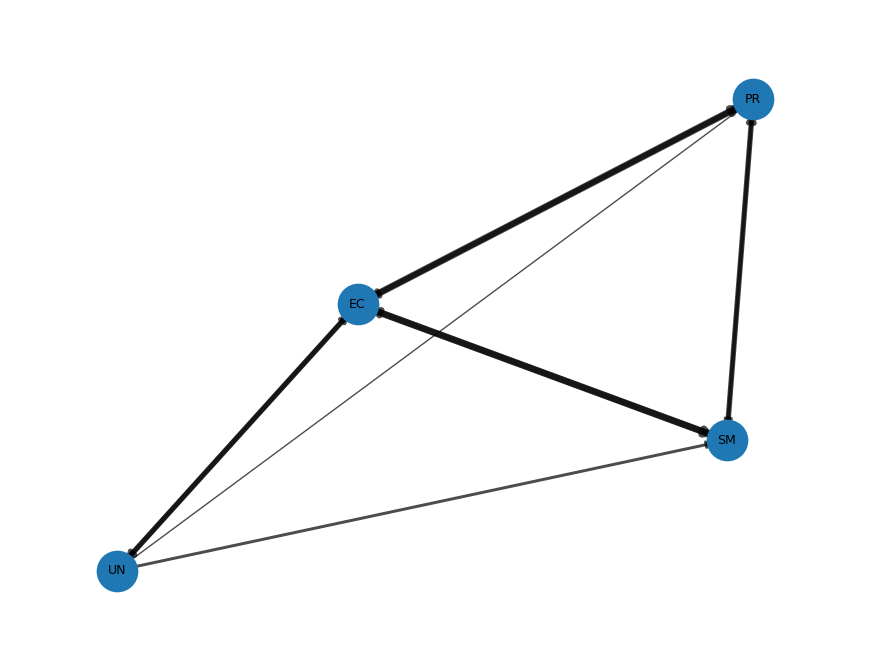

In [23]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

def cpdb_to_edges(df_summary, metric="MAX_across_runs", sum_cols=None,
                  directed=False, remove_self=True, threshold=0):
    """
    Returns an edge list (A, B, weight) from CellPhoneDB summary table.
    - metric: one column name to use for weights (e.g., 'MAX_across_runs')
    - sum_cols: list of column names to sum for the weight (ignored if metric provided)
    - directed: build a DiGraph if True
    - remove_self: drop A==B edges
    - threshold: drop edges with weight <= threshold
    """
    df = df_summary.reset_index().copy()

    if sum_cols is not None:
        df["weight"] = df[sum_cols].sum(axis=1)
    else:
        df["weight"] = df[metric]

    if remove_self:
        df = df[df["celltype_A"] != df["celltype_B"]]

    df = df[df["weight"] > threshold]

    cols = ["celltype_A", "celltype_B", "weight"]
    G = nx.from_pandas_edgelist(
        df[cols], "celltype_A", "celltype_B", edge_attr=["weight"],
        create_using=nx.DiGraph() if directed else nx.Graph()
    )
    return G

def plot_cpdb_network(G, seed=42, node_size=900, label_size=9):
    # spring layout; heavier edges pull nodes closer
    pos = nx.spring_layout(G, seed=seed, weight="weight")

    # scale edge widths nicely
    weights = np.array([d["weight"] for _, _, d in G.edges(data=True)])
    if len(weights) == 0:
        print("No edges to plot.")
        return
    w_scaled = 1 + 4 * (weights - weights.min()) / (weights.max() - weights.min() + 1e-9)

    plt.figure(figsize=(8, 6))
    nx.draw_networkx_edges(G, pos, width=w_scaled, alpha=0.7)
    nx.draw_networkx_nodes(G, pos, node_size=node_size)
    nx.draw_networkx_labels(G, pos, font_size=label_size)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

G_dir = cpdb_to_edges(summary_df, metric="VO", directed=True, threshold=0)
plot_cpdb_network(G_dir)

In [26]:
# group = "HO"

# adata = sc.read_h5ad(f"{work_dir}/adata/{group}.h5ad")
# means = pd.read_csv(glob.glob(f"{work_dir}/{group}.statistical/statistical_analysis_means_*.txt")[0], sep="\t")
# pvals = pd.read_csv(glob.glob(f"{work_dir}/{group}.statistical/statistical_analysis_pvalues_*.txt")[0], sep="\t")
# decon = pd.read_csv(glob.glob(f"{work_dir}/{group}.statistical/statistical_analysis_deconvoluted_*.txt")[0], sep="\t")

# kpy.plot_cpdb_heatmap(pvals=pvals, figsize=(6, 6), title=f"{group}: number of significant interactions")
# plt.show()

# df = kpy.plot_cpdb(
#     adata=adata,
#     cell_type1=".",
#     cell_type2=".",  # this means all cell-types
#     keep_significant_only=True,
#     means=means,
#     pvals=pvals,
#     celltype_key="cpdb_group",
#     figsize=(20, 8),
#     title=f"{group}: active interactions",
#     return_table=True,
# )

In [27]:
# group = "VCO"

# adata = sc.read_h5ad(f"{work_dir}/adata/{group}.h5ad")
# means = pd.read_csv(glob.glob(f"{work_dir}/{group}.statistical/statistical_analysis_means_*.txt")[0], sep="\t")
# pvals = pd.read_csv(glob.glob(f"{work_dir}/{group}.statistical/statistical_analysis_pvalues_*.txt")[0], sep="\t")
# decon = pd.read_csv(glob.glob(f"{work_dir}/{group}.statistical/statistical_analysis_deconvoluted_*.txt")[0], sep="\t")

# kpy.plot_cpdb_heatmap(pvals=pvals, figsize=(6, 6), title=f"{group}: number of significant interactions")
# plt.show()

# kpy.plot_cpdb(
#     adata=adata,
#     cell_type1=".",
#     cell_type2=".",  # this means all cell-types
#     keep_significant_only=True,
#     means=means,
#     pvals=pvals,
#     celltype_key="cpdb_group",
#     figsize=(20, 10),
#     title=f"{group}: active interactions",
# )

In [28]:
# group = "CA"

# adata = sc.read_h5ad(f"{work_dir}/adata/{group}.h5ad")
# means = pd.read_csv(glob.glob(f"{work_dir}/{group}.statistical/statistical_analysis_means_*.txt")[0], sep="\t")
# pvals = pd.read_csv(glob.glob(f"{work_dir}/{group}.statistical/statistical_analysis_pvalues_*.txt")[0], sep="\t")
# decon = pd.read_csv(glob.glob(f"{work_dir}/{group}.statistical/statistical_analysis_deconvoluted_*.txt")[0], sep="\t")

# kpy.plot_cpdb_heatmap(pvals=pvals, figsize=(6, 6), title=f"{group}: number of significant interactions")
# plt.show()

# kpy.plot_cpdb(
#     adata=adata,
#     cell_type1=".",
#     cell_type2=".",  # this means all cell-types
#     keep_significant_only=True,
#     means=means,
#     pvals=pvals,
#     celltype_key="cpdb_group",
#     figsize=(20, 8),
#     title=f"{group}: active interactions",
# )

In [29]:
# group = "VHO"

# adata = sc.read_h5ad(f"{work_dir}/adata/{group}.h5ad")
# means = pd.read_csv(glob.glob(f"{work_dir}/{group}.statistical/statistical_analysis_means_*.txt")[0], sep="\t")
# pvals = pd.read_csv(glob.glob(f"{work_dir}/{group}.statistical/statistical_analysis_pvalues_*.txt")[0], sep="\t")
# decon = pd.read_csv(glob.glob(f"{work_dir}/{group}.statistical/statistical_analysis_deconvoluted_*.txt")[0], sep="\t")

# kpy.plot_cpdb_heatmap(pvals=pvals, figsize=(6, 6), title=f"{group}: number of significant interactions")
# plt.show()

# kpy.plot_cpdb(
#     adata=adata,
#     cell_type1=".",
#     cell_type2=".",  # this means all cell-types
#     keep_significant_only=True,
#     means=means,
#     pvals=pvals,
#     celltype_key="cpdb_group",
#     figsize=(20, 8),
#     title=f"{group}: active interactions",
# )

In [31]:
# group = "VO"

# adata = sc.read_h5ad(f"{work_dir}/adata/{group}.h5ad")
# means = pd.read_csv(glob.glob(f"{work_dir}/{group}.statistical/statistical_analysis_means_*.txt")[0], sep="\t")
# pvals = pd.read_csv(glob.glob(f"{work_dir}/{group}.statistical/statistical_analysis_pvalues_*.txt")[0], sep="\t")
# decon = pd.read_csv(glob.glob(f"{work_dir}/{group}.statistical/statistical_analysis_deconvoluted_*.txt")[0], sep="\t")

# kpy.plot_cpdb_heatmap(pvals=pvals, figsize=(6, 6), title=f"{group}: number of significant interactions")
# plt.show()

# kpy.plot_cpdb(
#     adata=adata,
#     cell_type1=".",
#     cell_type2=".",  # this means all cell-types
#     keep_significant_only=True,
#     means=means,
#     pvals=pvals,
#     celltype_key="cpdb_group",
#     figsize=(20, 8),
#     title=f"{group}: active interactions",
# )